In [1]:
import re
from os import makedirs, path
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

from sklearn.preprocessing import MinMaxScaler # StandardScaler

<h3> 視覺畫圖表函數 </h3>

In [2]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # Windows 常見字體
plt.rcParams['axes.unicode_minus'] = False  # 解決座標軸負號顯示問題

In [3]:
makedirs('feature', exist_ok=True)

In [4]:
# 1. 提取特徵列
plot_cols = ['Average Fish Weight (g)', 'Survival Rate (%)',
       'Disease Occurrence (Cases)', 'Temperature (°C)',
       'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)',
       'Precipitation (inches)',]  # 提取指定的特徵

In [5]:
# 使用 箱線圖 來檢查特徵中的異常值。
def visualize_outliers(data):
    
    '''
    繪製箱線圖（Box Plot），可視化異常值。
    '''

    # 2. 定義顏色，與特徵列對應
    colors = ['blue', 'red', 'green', 'yellow', 'purple', 'orange', 'cyan', 'magenta', 'deeppink']

    # 3. 動態計算子圖佈局
    n_features = len(plot_cols)  # 特徵數量
    ncols = 2  # 每行顯示 3 個子圖
    nrows = (n_features + ncols - 1) // ncols  # 計算需要的行數（向上取整）

    # 4. 創建子圖
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))  # 動態設置子圖大小
    axs = axs.flatten()  # 將子圖矩陣展平成一維數組，方便索引
    fig.subplots_adjust(wspace=0.4, hspace=0.5)  # 調整子圖間距
    
    # 5. 繪製每個特徵的箱線圖
    for i, col in enumerate(plot_cols):
        axs[i].boxplot(data[col], patch_artist=True, boxprops=dict(facecolor=colors[i % len(colors)], alpha=0.6))
        axs[i].set_title(col, fontsize=12)  # 設置每個箱線圖的標題
        axs[i].set_ylabel("值", rotation=0)  # y 軸標籤
        axs[i].set_xticks([])  # 隱藏 y 軸刻度
        axs[i].set_xlabel(f"{col}", rotation=0) # x 軸標籤

    # 顯示圖表
    plt.tight_layout()
    plt.savefig('feature/Features Outlier Detection.png', bbox_inches='tight') # 儲存圖表，並且自動調整圖表的邊界，去除多餘的空白區域。
    plt.show()
    

In [6]:
# 使用 分佈圖 來檢查特徵中的異常值。
def visualize_distributions(data):
    
    '''
    繪製分佈圖，可視化異常值。
    '''
    n_features = len(plot_cols)
    ncols = 2
    nrows = (n_features + ncols - 1) // ncols

    # 創建子圖
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
    axs = axs.flatten() # 將子圖展平成一維陣列
    fig.subplots_adjust(wspace=0.4, hspace=0.5) # 調整子圖間距

    # 遍歷每個特徵，繪製直方圖
    for i, col in enumerate(plot_cols):
        sns.histplot(data[col], kde=True, ax=axs[i], color='orange', alpha=0.5)  # 繪製直方圖和KDE曲線 (kernel density estimation)
        axs[i].tick_params(axis='x', labelsize=10)  # # 設置 x 軸刻度和標籤大小。
        axs[i].set_title(col, fontsize=12) # 設置標題。

    # 顯示圖表
    plt.tight_layout()
    plt.savefig('feature/Features Distributions.png', bbox_inches='tight') # 儲存圖表，並且自動調整圖表的邊界，去除多餘的空白區域。
    plt.show()
    

In [7]:
# 將多個特徵（列）的數據繪製成子圖，並基於提供的日期時間索引進行繪製。
def visualize_df(data, date_times): 
    '''
    將多個特徵列在子圖中進行時間序列可視化。
    '''
    # 1. 提取數據和時間索引
    df = data
    date_time = date_times
    plot_cols = df.columns # 提取列名（特徵名）

    # 2. 定義顏色，與特徵列對應
    colors = ['blue', 'red', 'green', 'yellow', 'purple', 'orange', 'cyan', 'magenta', 'deeppink', 'brown', 'olive', 'teal', 'navy', 'darkorange']

    # 3. 設置繪圖特徵和時間索引
    plot_features = df[plot_cols] # 選擇所有特徵列
    plot_features.index = date_time # 將日期時間設為索引，方便繪圖

    # 4. 創建子圖
    fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(15, 20)) # 行列的子圖佈局
    fig.subplots_adjust(wspace=0.1, hspace=0.2) # 調整子圖之間的間距
    
     # 5. 遍歷每個特徵，並繪製到對應的子圖中
    for i, col in enumerate(plot_features): # 遍歷每個特徵（列名）
        row_idx = i // 2 # 確定當前特徵位於哪一行
        col_idx = i % 2  # 確定當前特徵位於哪一列
        axs[row_idx, col_idx].plot(plot_features[col], color=colors[i], label=col) # 繪製該特徵的數據
        axs[row_idx, col_idx].tick_params(axis='x', labelsize=7) # 指定顏色
        axs[row_idx, col_idx].legend() # 設置圖例為列名

    # 6. 顯示圖表
    plt.tight_layout()
    plt.savefig('feature/Features Analysis.png', bbox_inches='tight') # 儲存圖表，並且自動調整圖表的邊界，去除多餘的空白區域。
    plt.show()
    

In [8]:
def sanitize_filename(name):
    """
    移除/替換檔名中不合法的字元。
    """
    return re.sub(r'[\\/:*?"<>|]', '_', name)

In [9]:
# 繪製時間序列數據及其異常值（outliers）的函數。
def plot_outlier(ts, n_column, ewm_span=100, threshold=3.0):
    '''
    利用 指數加權移動平均（EWMA） 來檢測異常。
    1.) ts：需要檢測異常值的時間序列資料，應該是 pandas.Series 型態。
    2.) n_column：圖表的標題，通常是欄位名稱，用來指明是哪個特徵（feature）。
    3.) ewm_span：控制指數加權移動平均的平滑度，越高的值使平滑效果越強（默認為 100）。
    4.) threshold：異常值的檢測閾值，以標準差為單位，默認為 3.0，即數值偏離均值超過 3 個標準差會被認為是異常值。
    '''
    assert type(ts) == pd.Series # 確保 ts 是一個 pandas.Series 型態，否則會報錯。
    fig, ax = plt.subplots(figsize=(15,5)) # 建立圖表，並設置圖表大小為 15x5。
    ewm_mean = ts.ewm(span=ewm_span).mean()  # 計算時間序列的指數加權移動平均值（EWMA）。
    ewm_std = ts.ewm(span=ewm_span).std()  # 計算時間序列的指數加權標準差，用來判斷異常值。
    ax.plot(ts, label='original') # 繪製原始時間序列數據。
    ax.plot(ewm_mean, label='ewma') # 繪製指數加權移動平均線，提供平滑的數據趨勢。

    # plot data which deviate from range during mean ±  3 * std as outlier 
    ax.fill_between(ts.index,
                    ewm_mean - ewm_std * threshold,
                    ewm_mean + ewm_std * threshold,
                    alpha=0.2) # 填充一個區域，範圍為平均值加減 3 倍標準差（可以根據 threshold 調整），用來表示「正常區域」。位於此區域外的數據將視為異常值。
    outlier = ts[(ts - ewm_mean).abs() > ewm_std * threshold] # 篩選出超出正常區域的異常值。
    ax.scatter(outlier.index, outlier, label='outlier') # 使用散點圖標記異常值的位置。
    ax.legend() # 添加圖例，標示出原始數據、移動平均線和異常值。
    plt.title(n_column) # 設置圖表標題為指定的欄位名稱（n_column）。
    safe_name = sanitize_filename(n_column)
    plt.savefig(f'feature/{safe_name}.png') # 儲存圖表

<h3> IoT Monitoring Dataset of Water Quality and Tilapia </h3>

In [10]:
# 讀取數據
df = pd.read_excel(r'Data_Model_IoTMLCQ_2024.xlsx')
df

,Datetime,Month,Average Fish Weight (g),Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Month_Num,...,day,hour,oxigeno_scaled,ph,turbidez,Oxygenation Automatic,Corrective Measures,Thermal Risk Index,Low Oxygen Alert,Health Status
0,2024-01-01 00:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.30,1.0,...,1.0,0.0,8.355273,0.387898,0.020505,Yes,No,Normal,Safe,Stable
1,2024-01-01 01:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.30,1.0,...,1.0,1.0,8.256397,0.343950,0.108561,No,No,Normal,Safe,Stable
2,2024-01-01 02:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.30,1.0,...,1.0,2.0,8.511549,0.365285,0.410457,Yes,No,Normal,Safe,Stable
3,2024-01-01 03:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.30,1.0,...,1.0,3.0,8.362301,0.189601,0.891217,No,No,Normal,Safe,Stable
4,2024-01-01 04:00:00,January,275.82,95.27,2.0,27.47,6.34,7.98,3.30,1.0,...,1.0,4.0,8.003350,0.318775,0.936614,Yes,No,Normal,Safe,Stable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4378,2024-07-01 10:00:00,July,262.82,92.85,1.0,27.45,7.72,7.88,3.71,6.0,...,28.0,5.0,8.307432,0.360661,0.014110,Yes,No,Normal,Safe,Stable
4379,2024-07-01 11:00:00,July,262.82,92.85,1.0,27.45,7.72,7.88,3.71,6.0,...,28.0,5.0,8.307432,0.360661,0.014110,No,No,Normal,Safe,Stable
4380,2024-07-01 12:00:00,July,262.82,92.85,1.0,27.45,7.72,7.88,3.71,6.0,...,28.0,5.0,8.307432,0.360661,0.014110,Yes,No,Normal,Safe,Stable
4381,2024-07-01 13:00:00,July,262.82,92.85,1.0,27.45,7.72,7.88,3.71,6.0,...,28.0,5.0,8.307432,0.360661,0.014110,No,No,Normal,Safe,Stable


In [11]:
df.dtypes
df.info() # 查看是否有缺失值。

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Datetime                    4383 non-null   datetime64[ns]
 1   Month                       4383 non-null   object        
 2   Average Fish Weight (g)     4383 non-null   float64       
 3   Survival Rate (%)           4383 non-null   float64       
 4   Disease Occurrence (Cases)  4383 non-null   float64       
 5   Temperature (°C)            4383 non-null   float64       
 6   Dissolved Oxygen (mg/L)     4383 non-null   float64       
 7   pH                          4383 non-null   float64       
 8   Turbidity (NTU)             4383 non-null   float64       
 9   Month_Num                   4383 non-null   float64       
 10  month_x                     4383 non-null   float64       
 11  Oxygenation Interventions   4383 non-null   int64       

In [12]:
# Dropping the unnecessary columns 移除非必要欄位
columns_to_drop = ['Month', 'Month_Num', 'month_x', 'Average Temperature (°C)', 'High Temperature (°C)', 'Low Temperature (°C)', 
                  'month_y', 'day', 'hour', 'oxigeno_scaled', 'ph', 'turbidez', 'Low Oxygen Alert']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['Datetime', 'Average Fish Weight (g)', 'Survival Rate (%)',
       'Disease Occurrence (Cases)', 'Temperature (°C)',
       'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)',
       'Oxygenation Interventions', 'Corrective Interventions',
       'Precipitation (inches)', 'Oxygenation Automatic',
       'Corrective Measures', 'Thermal Risk Index', 'Health Status'],
      dtype='object')

In [13]:
column_order = [
    # 🕒 時間標記
    'Datetime',
    
    # 🧬 健康指標
    'Survival Rate (%)',
    'Disease Occurrence (Cases)',
    
    # 🌊 環境特徵
    'Temperature (°C)',
    'Dissolved Oxygen (mg/L)',
    'pH',
    'Turbidity (NTU)',
    'Precipitation (inches)',
        
    # 🎯 預測目標
    'Average Fish Weight (g)',
]

df= df[column_order]
df

,Datetime,Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Fish Weight (g)
0,2024-01-01 00:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
1,2024-01-01 01:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2,2024-01-01 02:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
3,2024-01-01 03:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
4,2024-01-01 04:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
...,...,...,...,...,...,...,...,...,...
4378,2024-07-01 10:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
4379,2024-07-01 11:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
4380,2024-07-01 12:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
4381,2024-07-01 13:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82


In [14]:
# 移除特徵欄位
# ⚠️ 風險與健康
'Thermal Risk Index',
'Health Status',

# 🧪 管理介入
'Oxygenation Interventions',
'Corrective Interventions',
'Oxygenation Automatic',
'Corrective Measures',

('Corrective Measures',)

In [15]:
# # 二元類別轉為 0/1
# df['Oxygenation Automatic'] = df['Oxygenation Automatic'].map({'No': 0, 'Yes': 1})
# df['Corrective Measures'] = df['Corrective Measures'].map({'No': 0, 'Yes': 1})
# df['Thermal Risk Index'] = df['Thermal Risk Index'].map({'Normal': 0, 'High': 1})
# df['Health Status'] = df['Health Status'].map({'Stable': 0, 'At Risk': 1})
# print(df.columns)
# df

In [16]:
# 建議特徵選擇
[
    'Temperature (°C)', 
    'Dissolved Oxygen (mg/L)', 
    'pH', 
    'Turbidity (NTU)', 
    'Oxygenation Automatic (binary)', 
    'Oxygenation Interventions (binary)', 
    'Corrective Interventions', 
    'Survival Rate (%)'  # 選擇性加入
]

# 或

[
    'Survival Rate (%)', 'Disease Occurrence (Cases)', 'Temperature (°C)',
    'Dissolved Oxygen (mg/L)', 'pH', 'Turbidity (NTU)',
    'Precipitation (inches)', 'Oxygenation Interventions',
    'Corrective Interventions', 'Oxygenation Automatic',
    'Thermal Risk Index'  # 可刪除 Corrective Measures 或留其中一項
]

['Survival Rate (%)',
 'Disease Occurrence (Cases)',
 'Temperature (°C)',
 'Dissolved Oxygen (mg/L)',
 'pH',
 'Turbidity (NTU)',
 'Precipitation (inches)',
 'Oxygenation Interventions',
 'Corrective Interventions',
 'Oxygenation Automatic',
 'Thermal Risk Index']

In [17]:
# 將Datetime設為index
df['Datetime'] = pd.to_datetime(df['Datetime']) # 1. 轉換為 datetime 格式
df = df.sort_values('Datetime')  # 2. 依時間排序
df.set_index('Datetime', inplace=True) # 3. 將 'Datetime' 設為索引
df

,Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Fish Weight (g)
Datetime,,,,,,,,
2024-01-01 00:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 01:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 02:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 03:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 04:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
...,...,...,...,...,...,...,...,...
2024-07-01 10:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
2024-07-01 11:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
2024-07-01 12:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82


<h3> 畫出視覺化數據 </h3>

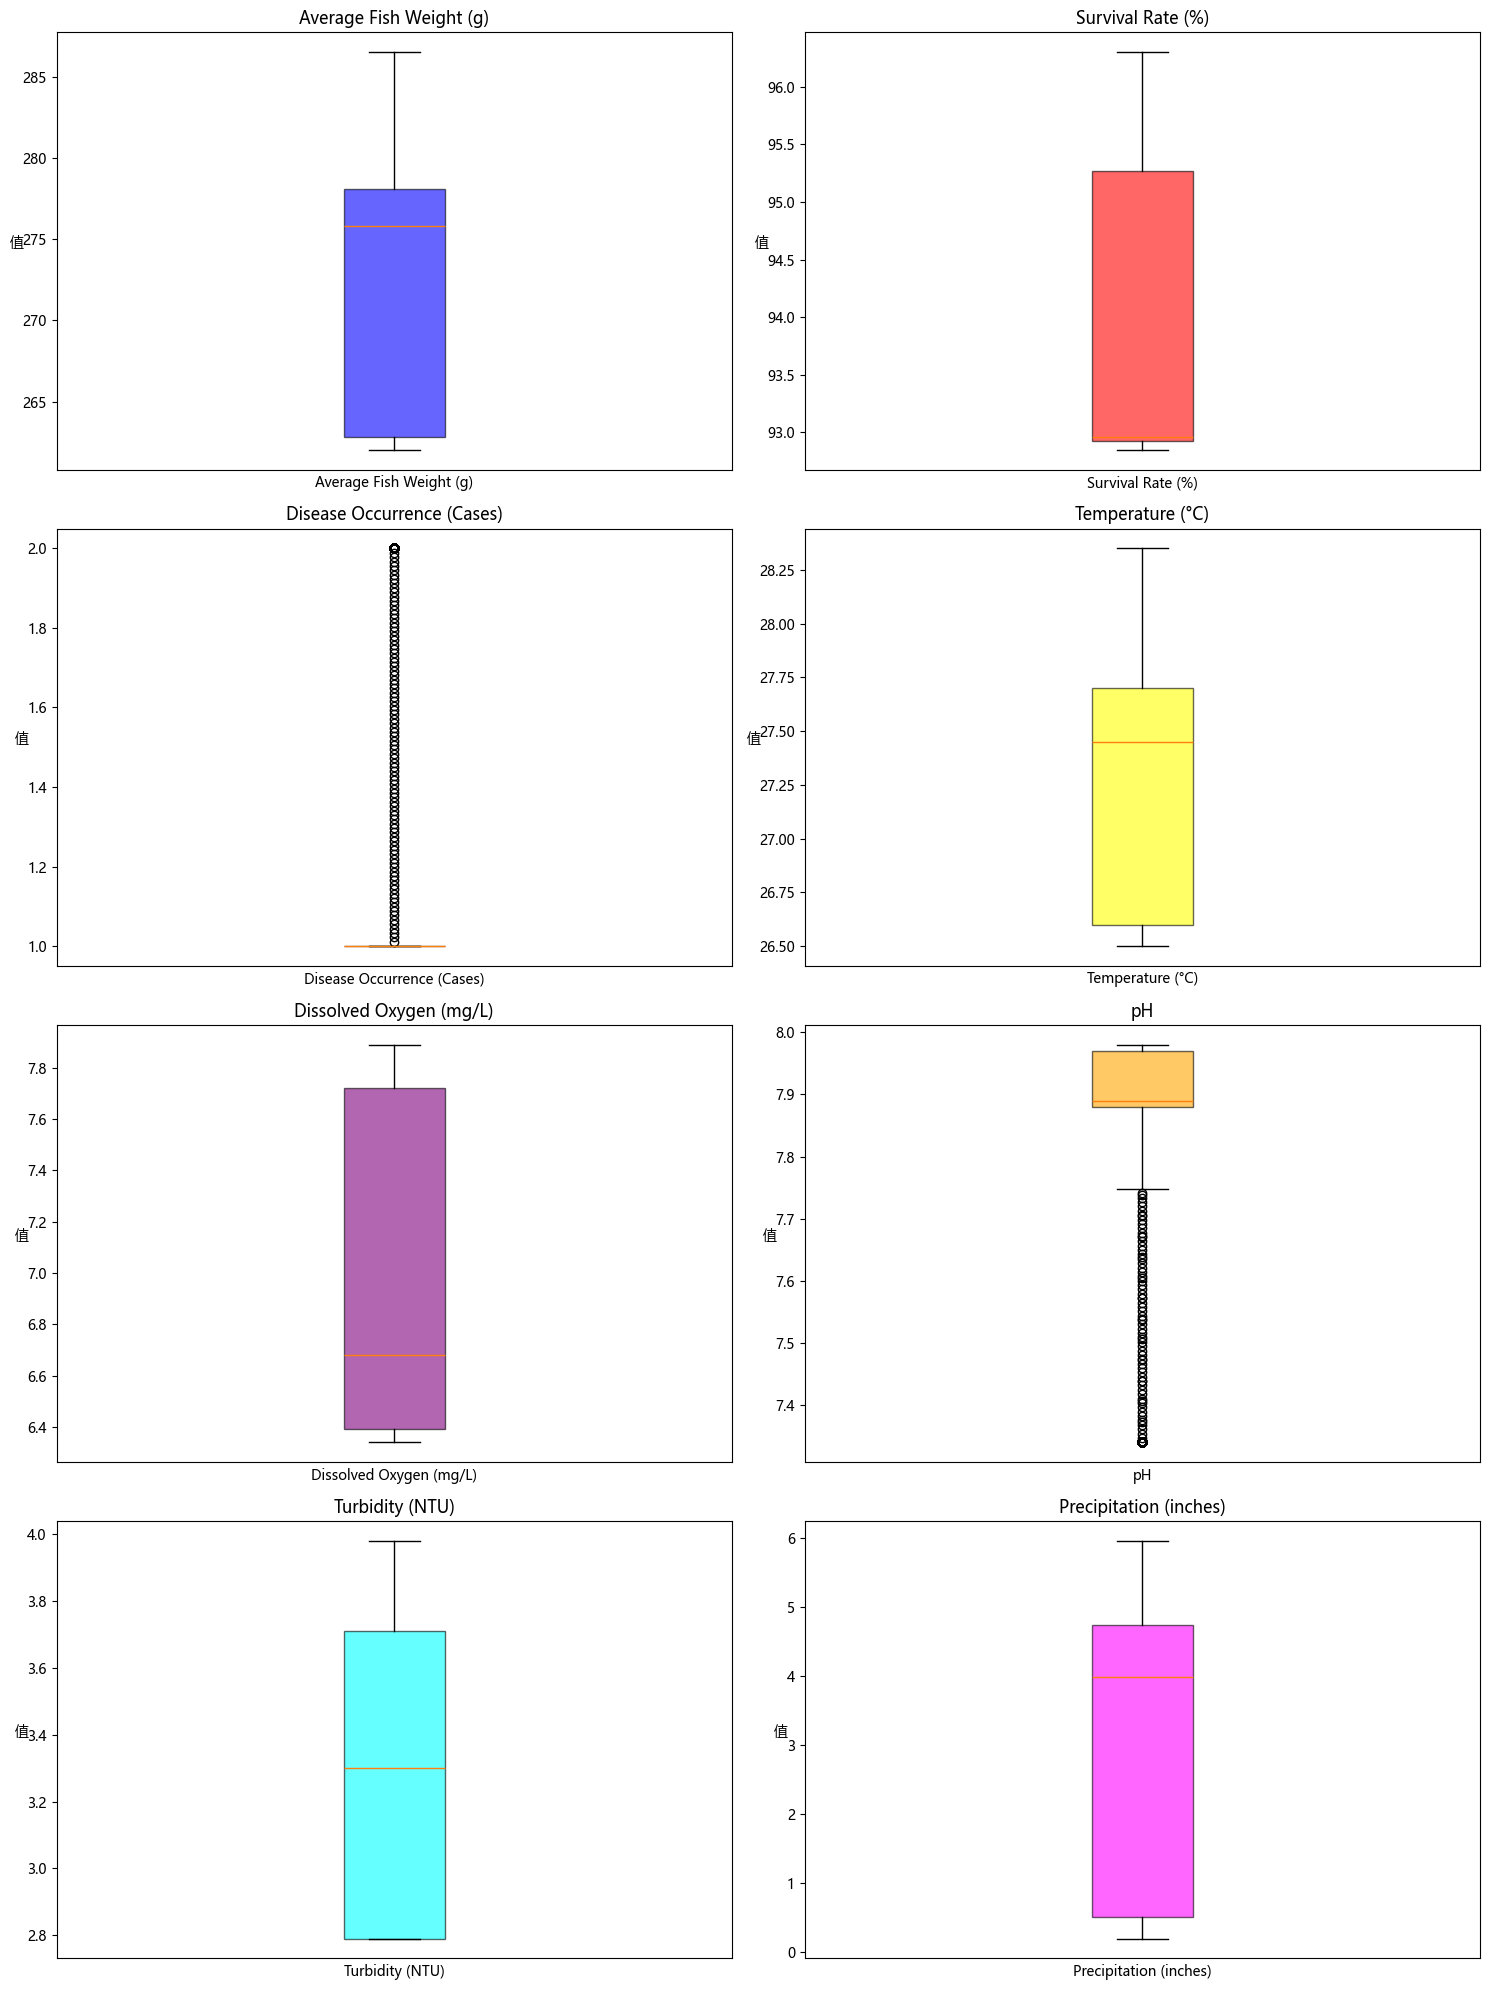

In [18]:
# 使用 箱線圖 來檢查特徵中的異常值。
visualize_outliers(df)

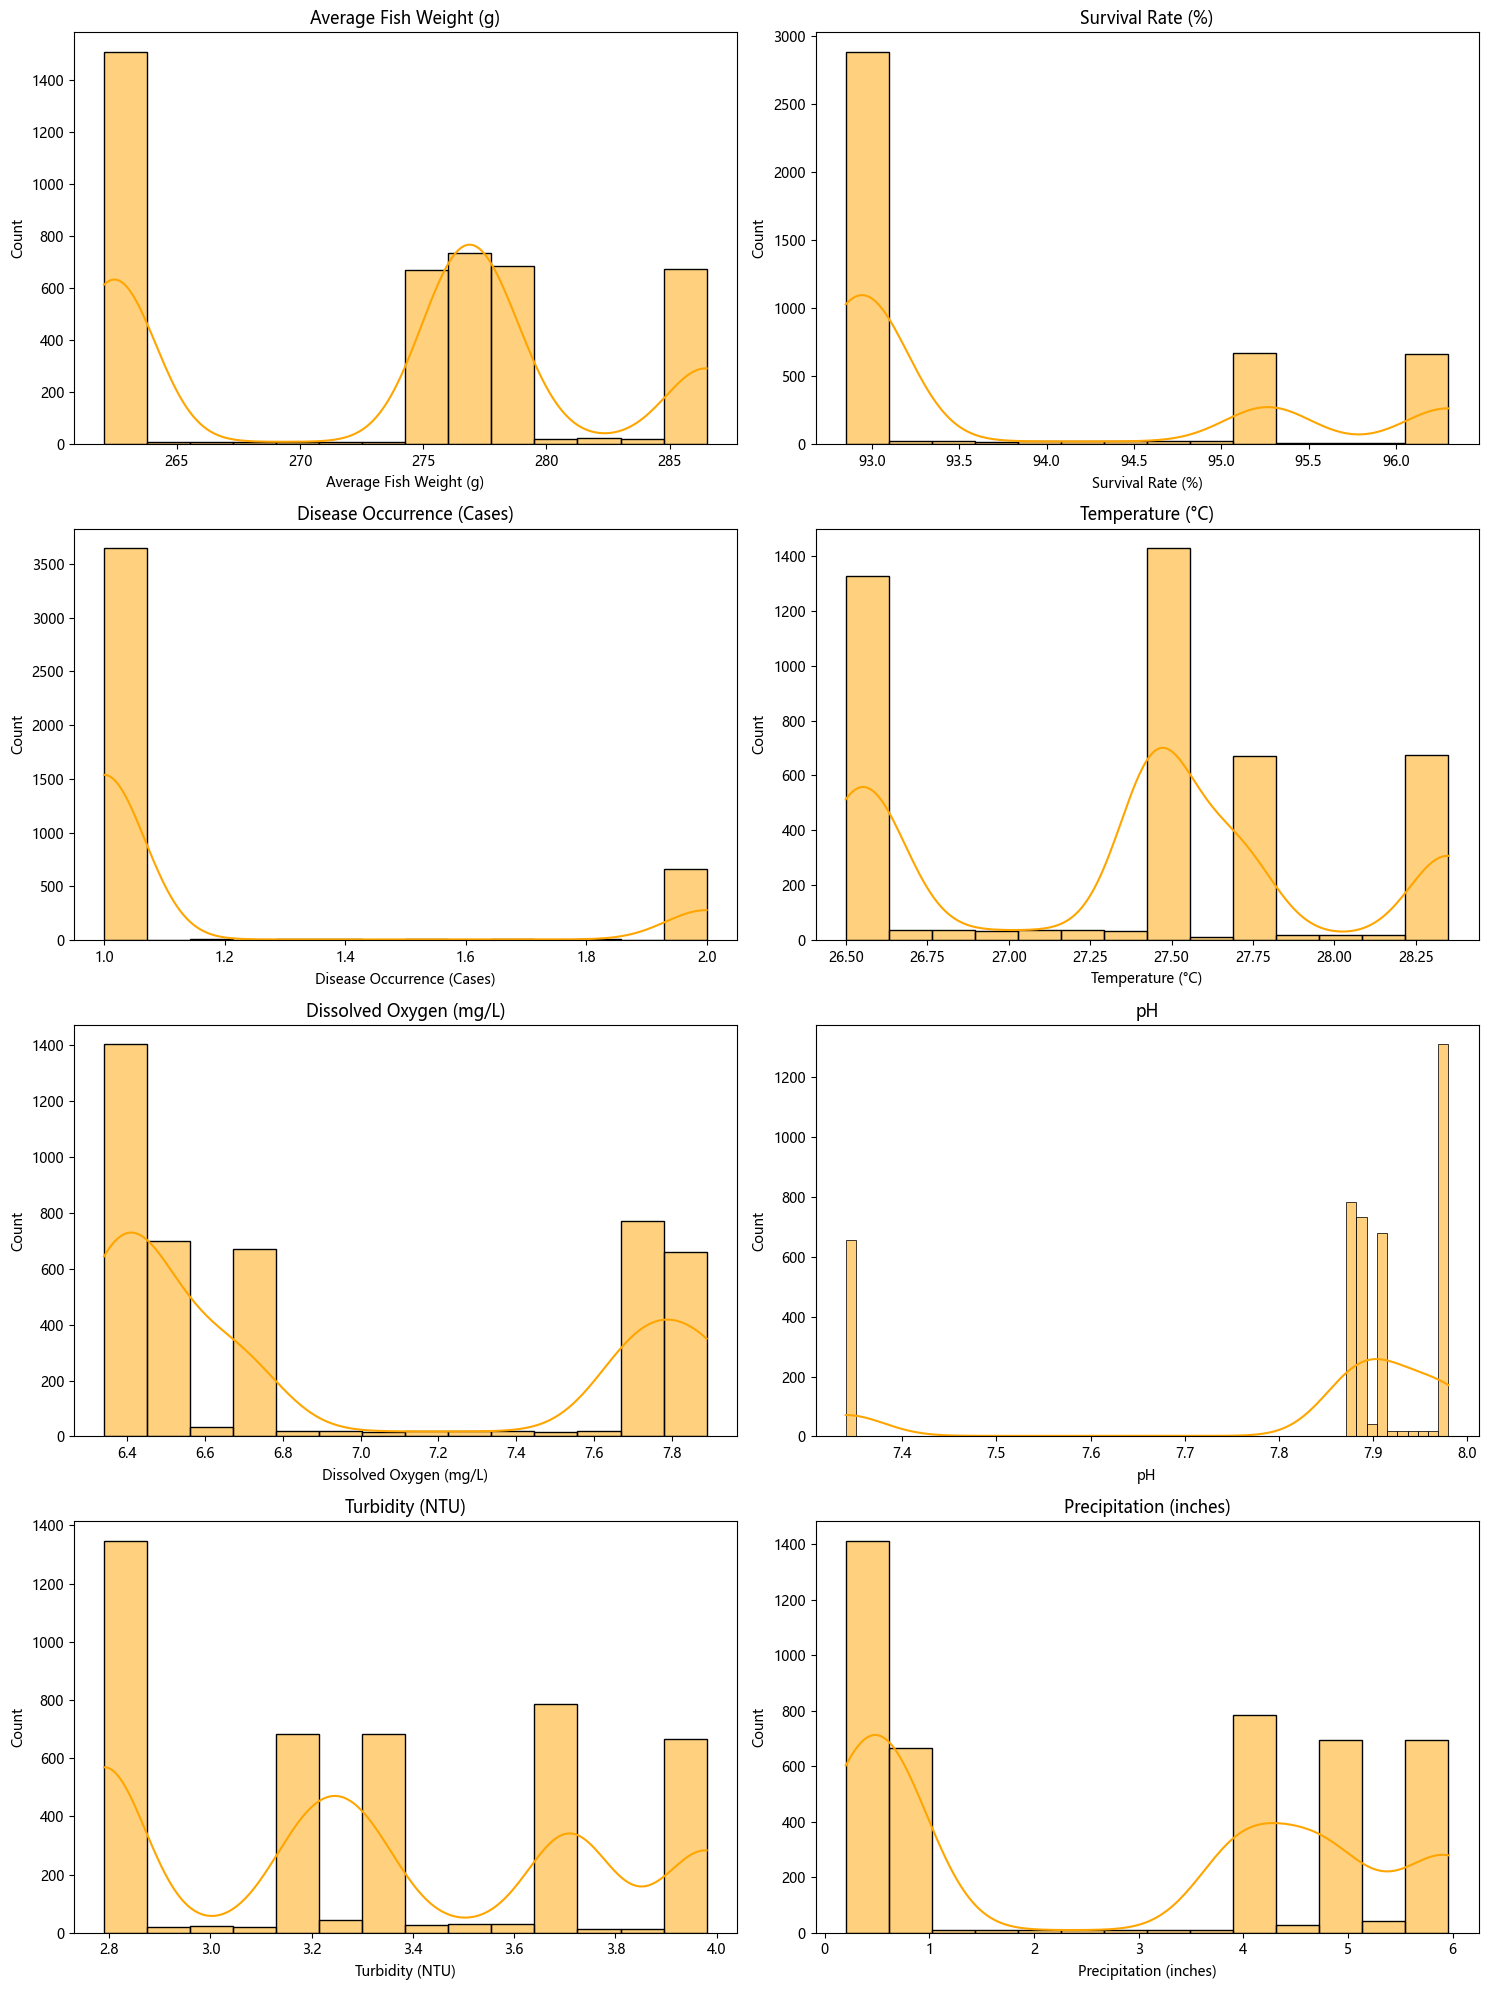

In [19]:
# 使用 分佈圖 來檢查特徵中的異常值。
visualize_distributions(df)

<ol> 直方圖（Histogram）：
    <li> 橙色部分：展示了特徵數據的分佈情況。（每個區間內的數據量） </li>
    <li> 橙色曲線：核密度估計，用於平滑數據分佈，幫助我們了解數據的大致趨勢和分佈形狀。 </li>
</ol>

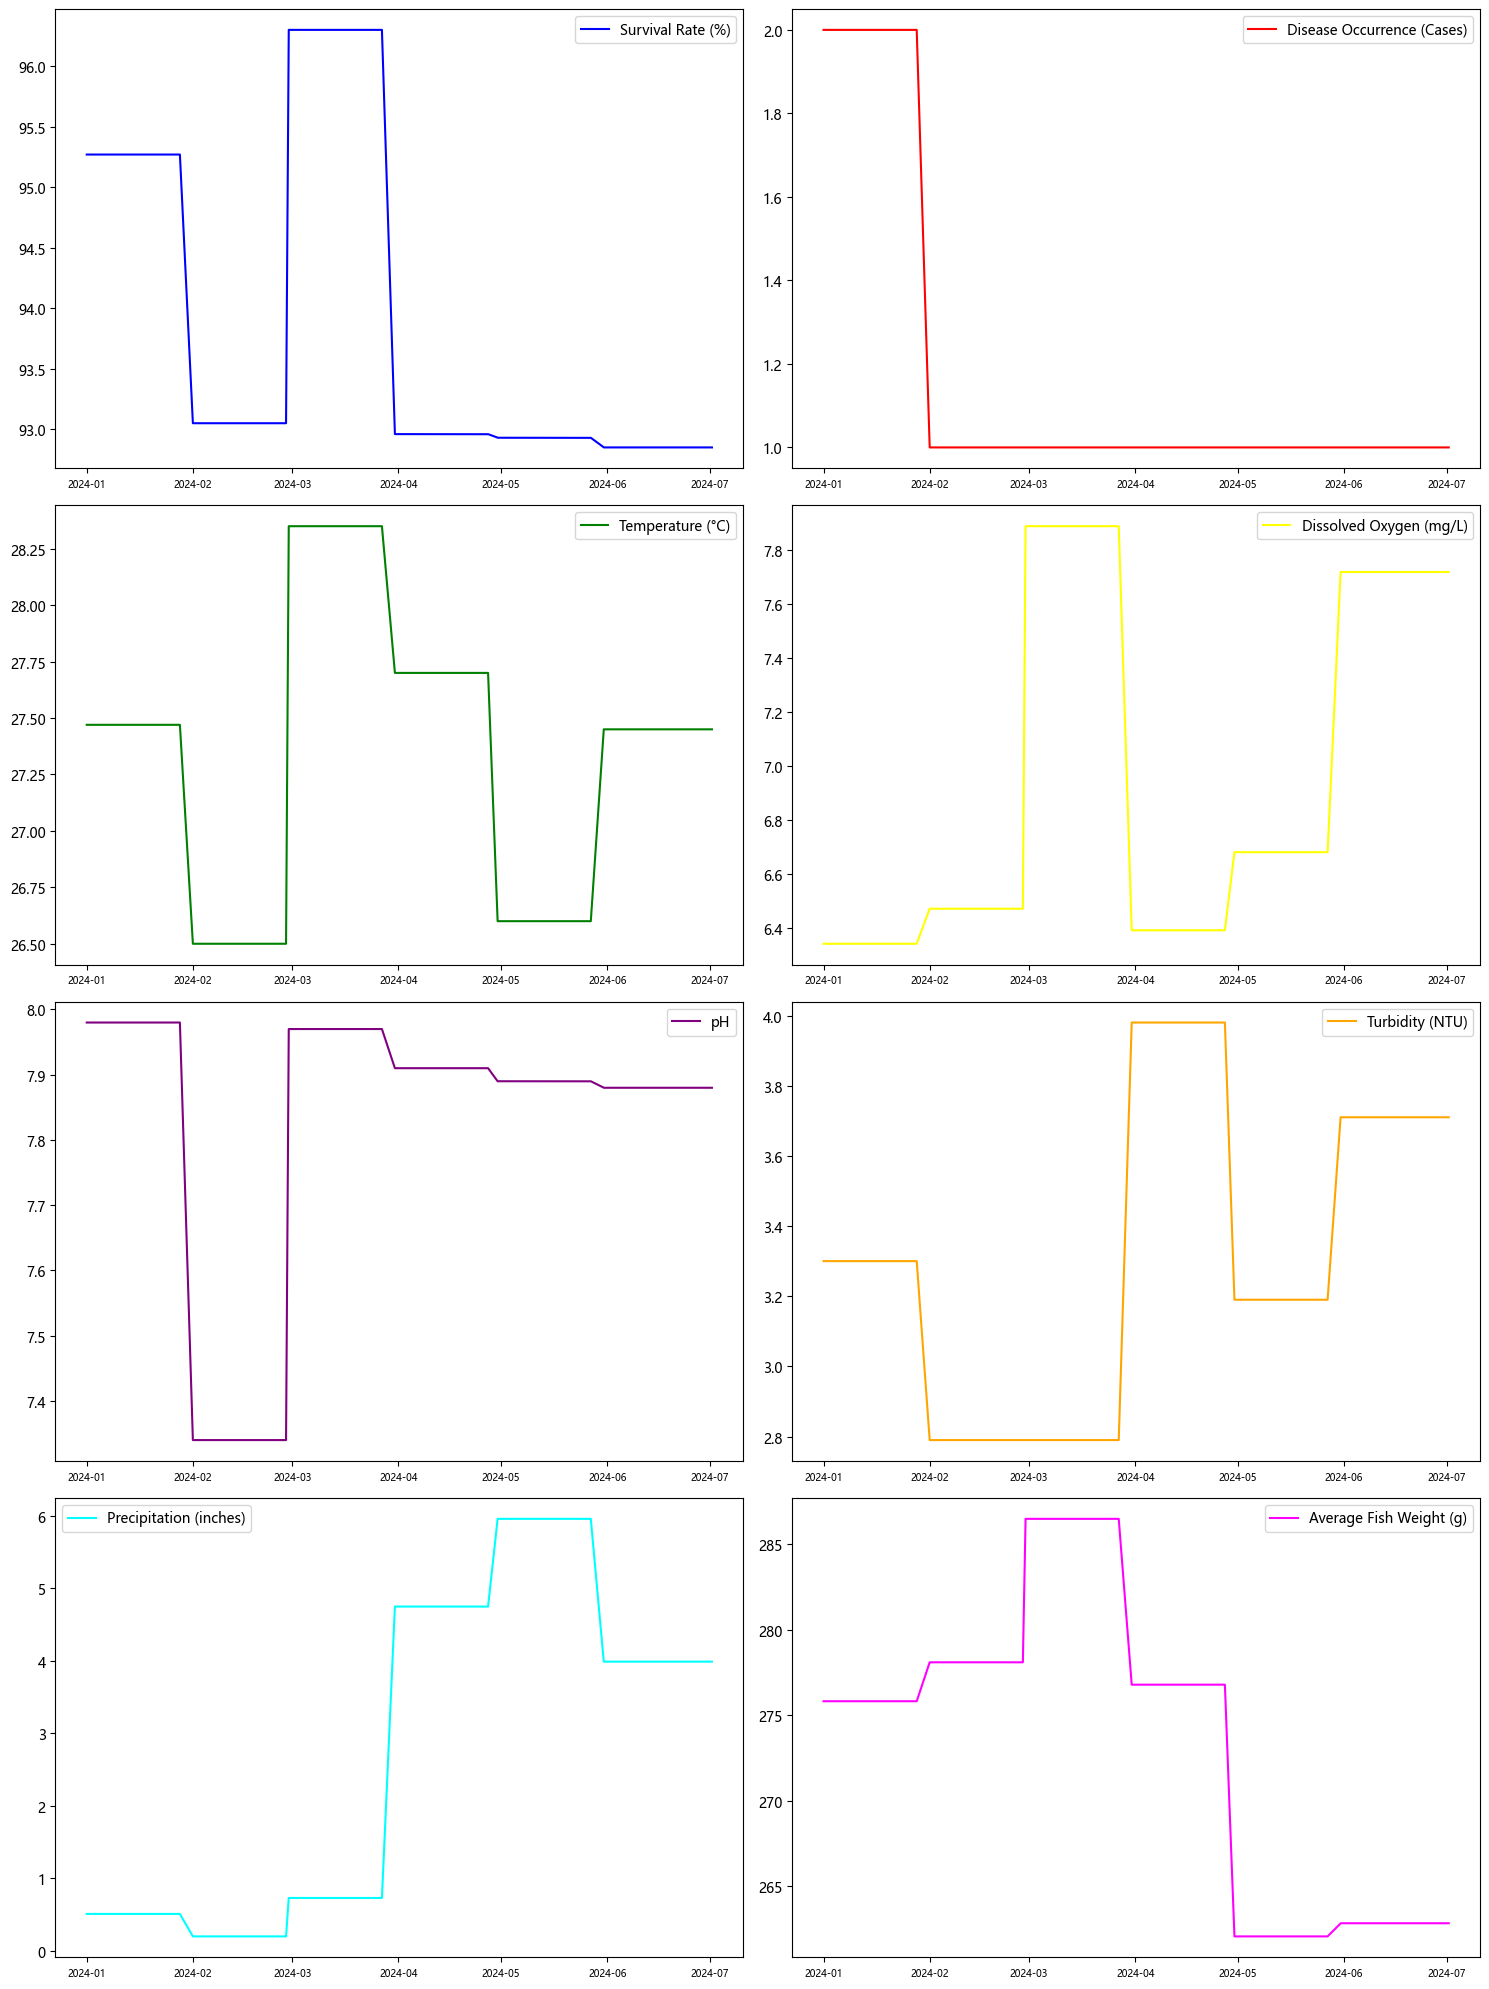

In [20]:
#visualizing a dataframe
# 將多個特徵（列）的數據繪製成子圖，並基於提供的日期時間索引進行繪製。
visualize_df(df, df.index)

In [21]:
#敘述統計
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Survival Rate (%),4383.0,93.857269,1.337427,92.85,92.93,92.96,95.27,96.30
Disease Occurrence (Cases),4383.0,1.159480,0.361408,1.00,1.00,1.00,1.00,2.00
Temperature (°C),4383.0,27.344908,0.619734,26.50,26.60,27.45,27.70,28.35
Dissolved Oxygen (mg/L),4383.0,6.929651,0.631683,6.34,6.39,6.68,7.72,7.89
pH,4383.0,7.829938,0.214384,7.34,7.88,7.89,7.97,7.98
Turbidity (NTU),4383.0,3.305640,0.431041,2.79,2.79,3.30,3.71,3.98
Precipitation (inches),4383.0,2.752136,2.260136,0.20,0.51,3.99,4.75,5.96
Average Fish Weight (g),4383.0,273.391088,8.675050,262.05,262.82,275.82,278.10,286.50


<p style='color: blue'> 針對 Average Fish Weight (g) 吳郭魚的重量特別繪製！ </p>

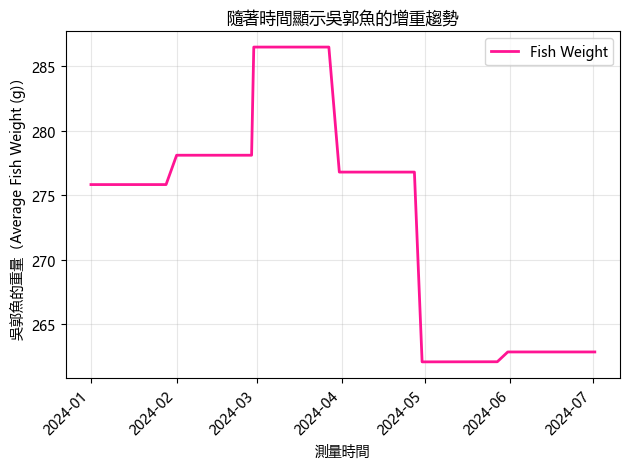

In [22]:
plt.plot(df.index, df['Average Fish Weight (g)'], color='deeppink', linewidth=2, label='Fish Weight')

# 设置图表标题和标签
plt.title('隨著時間顯示吳郭魚的增重趨勢')

# 修正 x 軸
plt.gcf().autofmt_xdate()  # 自動調整日期格式和角度
plt.xticks(rotation=45)    # 將 x 軸標籤旋轉 45 度以避免重疊
plt.xlabel('測量時間')

plt.ylabel('吳郭魚的重量（Average Fish Weight (g)）')
plt.legend(loc='best', bbox_to_anchor=(1, 1))  # Moves the legend outside the plot
plt.grid(True, alpha=0.3)  # 显示网格
plt.xticks()  # 日期标签旋转，便于阅读 #rotation=45

# 显示图形
plt.tight_layout()
plt.savefig('feature/Fish Weight Growth Trend.png', bbox_inches='tight') # 儲存圖表，並且自動調整圖表的邊界，去除多餘的空白區域。
plt.show()


In [23]:
df.to_csv('IoT Monitoring Dataset of Water Quality and Tilapia.csv')

<h3> 根據平均體重變動量自動切段（ΔFishWeight） </h3>

In [24]:
# df['FishWeight_Δ'] = df['Average Fish Weight (g)'].diff()

# # 找出 Δ 變化大於某門檻的地方
# threshold = 3.0  # 你可以調整門檻
# df['is_jump'] = df['FishWeight_Δ'].abs() > threshold

# # 標記段落（每次 jump 就新段）
# df['group_id'] = df['is_jump'].cumsum()

In [25]:
# import matplotlib.pyplot as plt

# for g, sub in df.groupby('group_id'):
#     plt.plot(sub.index, sub['Average Fish Weight (g)'], label=f'group {g}')
    
# plt.legend()
# plt.title("段落分段後魚體重趨勢")
# plt.xlabel("Datetime")
# plt.ylabel("Average Fish Weight (g)")
# plt.xticks(rotation=45)  # 可選：讓時間軸不重疊
# plt.tight_layout()
# plt.show()


<h3> 根據平均體重手動切段（Average Fish Weight (g)） </h3>

In [26]:
# Step 1：定義分段時間
seg1_start = "2024-01-01"
seg1_end   = "2024-02-27"

seg2_start = "2024-02-28"
seg2_end   = "2024-04-29"

seg3_start = "2024-04-30"
seg3_end   = "2024-07-01"

# Step 2：用時間範圍切出資料段
df_seg1 = df.loc[seg1_start:seg1_end].copy()
df_seg2 = df.loc[seg2_start:seg2_end].copy()
df_seg3 = df.loc[seg3_start:seg3_end].copy()

In [27]:
df_seg1

,Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Fish Weight (g)
Datetime,,,,,,,,
2024-01-01 00:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 01:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 02:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 03:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
2024-01-01 04:00:00,95.27,2.0,27.47,6.34,7.98,3.30,0.51,275.82
...,...,...,...,...,...,...,...,...
2024-02-27 19:00:00,93.05,1.0,26.50,6.47,7.34,2.79,0.20,278.10
2024-02-27 20:00:00,93.05,1.0,26.50,6.47,7.34,2.79,0.20,278.10
2024-02-27 21:00:00,93.05,1.0,26.50,6.47,7.34,2.79,0.20,278.10


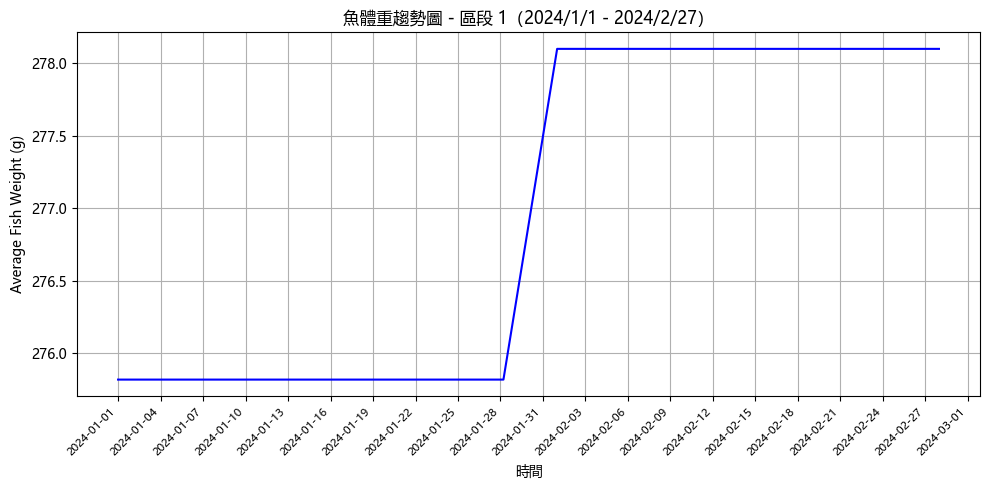

In [28]:
import matplotlib.dates as mdates

# Segment 1
plt.figure(figsize=(10, 5))
plt.plot(df_seg1.index, df_seg1['Average Fish Weight (g)'], color='blue')

# 顯示所有日期：每天顯示標籤
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))  # 每一天一格
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # 日期格式

plt.xticks(rotation=45, ha='right', fontsize=8)  # 旋轉日期以防重疊
plt.title("魚體重趨勢圖 - 區段 1（2024/1/1 - 2024/2/27）")
plt.xlabel("時間")
plt.ylabel("Average Fish Weight (g)")
plt.grid(True)
plt.tight_layout()
plt.show()

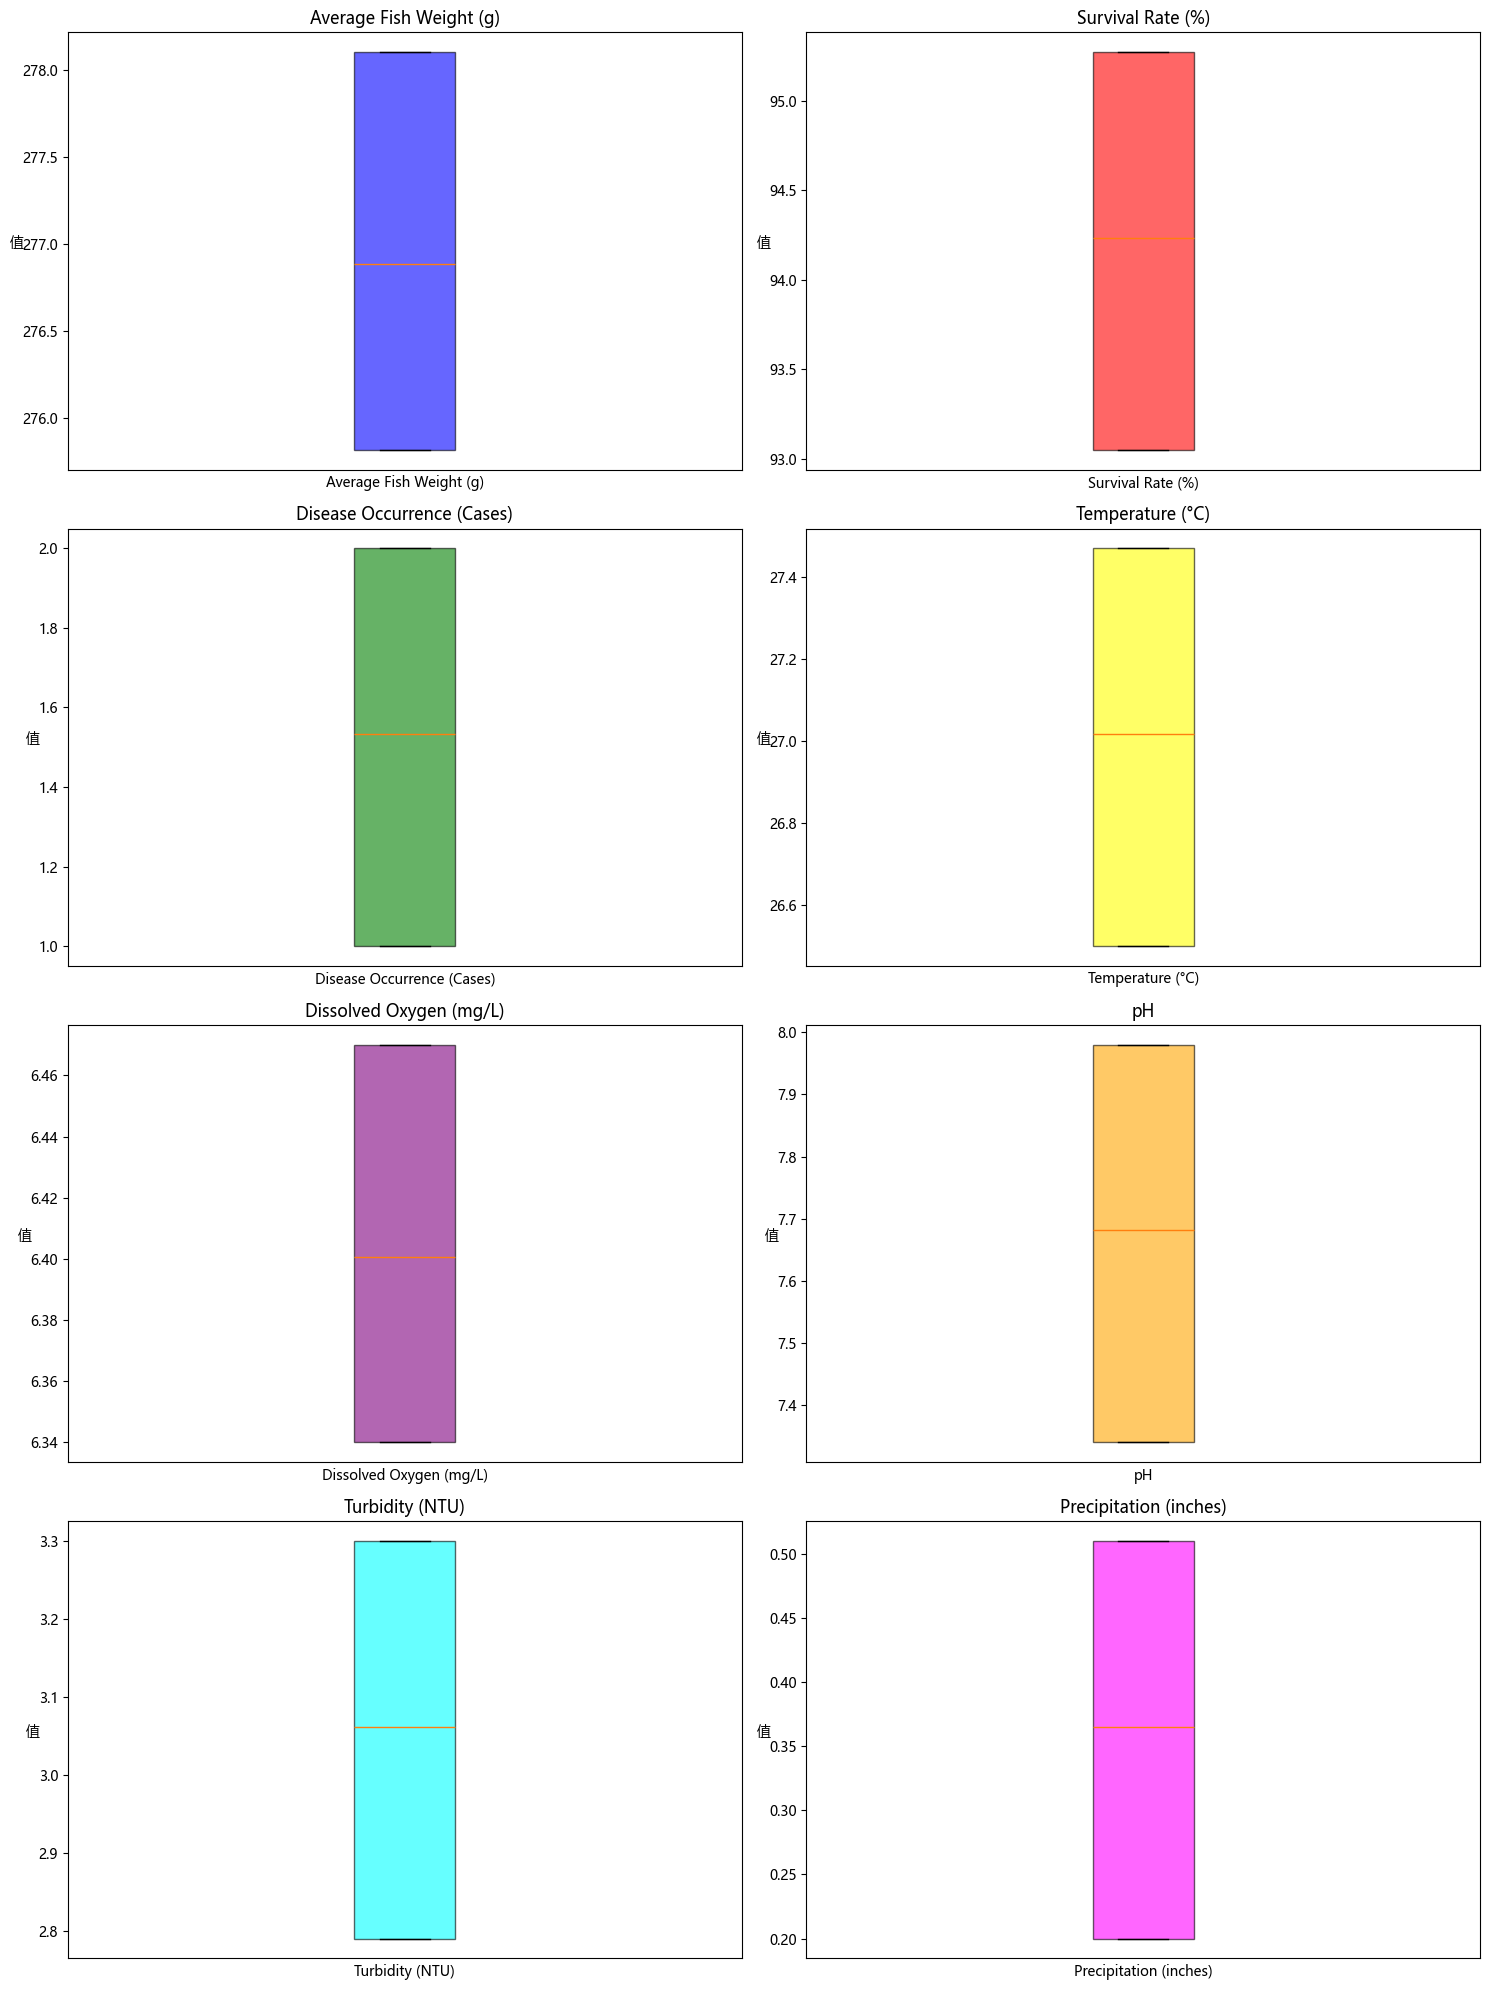

In [29]:
visualize_outliers(df_seg1)

In [30]:
df_seg1.to_csv('IoT Monitoring Dataset of Water Quality and Tilapia_Segment01.csv')

In [31]:
df_seg2

,Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Fish Weight (g)
Datetime,,,,,,,,
2024-02-28 00:00:00,93.050000,1.0,26.500000,6.470000,7.340000,2.790000,0.200000,278.10
2024-02-28 01:00:00,93.050000,1.0,26.500000,6.470000,7.340000,2.790000,0.200000,278.10
2024-02-28 02:00:00,93.050000,1.0,26.500000,6.470000,7.340000,2.790000,0.200000,278.10
2024-02-28 03:00:00,93.050000,1.0,26.500000,6.470000,7.340000,2.790000,0.200000,278.10
2024-02-28 04:00:00,93.050000,1.0,26.500000,6.470000,7.340000,2.790000,0.200000,278.10
...,...,...,...,...,...,...,...,...
2024-04-29 19:00:00,92.932239,1.0,26.682090,6.658358,7.891493,3.248955,5.869701,263.15
2024-04-29 20:00:00,92.931791,1.0,26.665672,6.662687,7.891194,3.237164,5.887761,262.93
2024-04-29 21:00:00,92.931343,1.0,26.649254,6.667015,7.890896,3.225373,5.905821,262.71


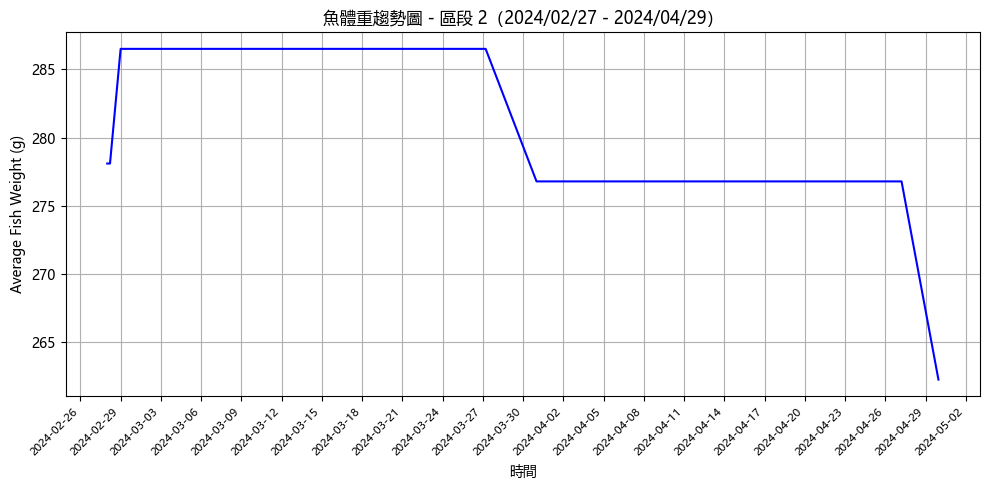

In [32]:
# Segment 2
plt.figure(figsize=(10, 5))
plt.plot(df_seg2.index, df_seg2['Average Fish Weight (g)'], color='blue')

# 顯示所有日期：每天顯示標籤
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))  # 每一天一格
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # 日期格式

plt.xticks(rotation=45, ha='right', fontsize=8)  # 旋轉日期以防重疊
plt.title("魚體重趨勢圖 - 區段 2（2024/02/27 - 2024/04/29）")
plt.xlabel("時間")
plt.ylabel("Average Fish Weight (g)")
plt.grid(True)
plt.tight_layout()
plt.show()

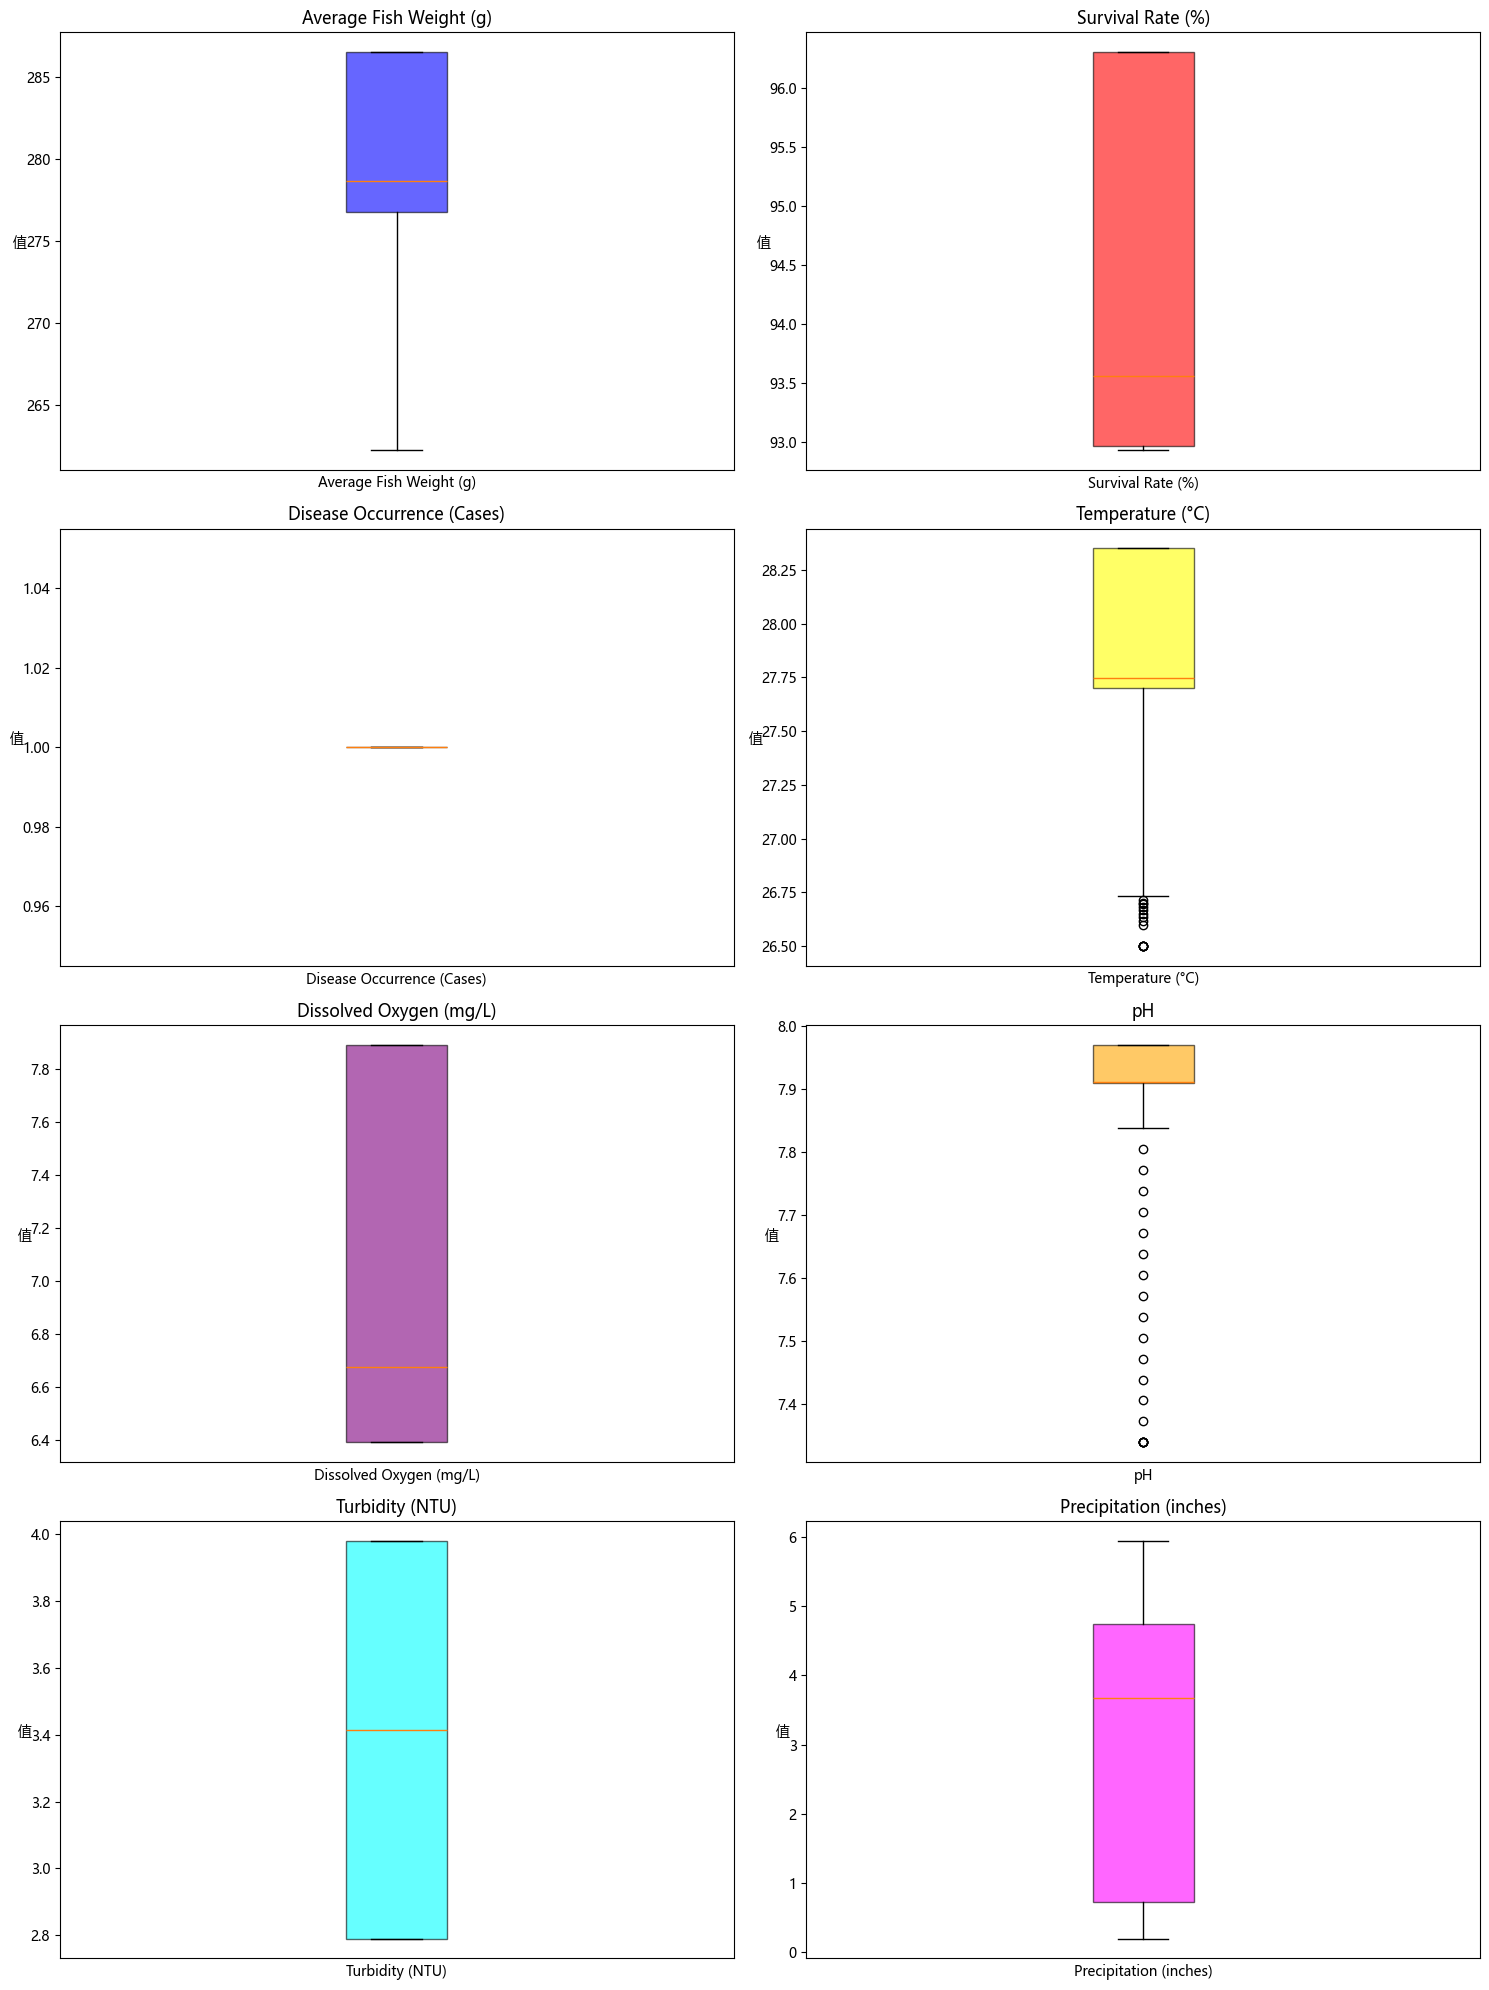

In [33]:
visualize_outliers(df_seg2)

In [34]:
df_seg2.to_csv('IoT Monitoring Dataset of Water Quality and Tilapia_Segment02.csv')

In [35]:
df_seg3

,Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Fish Weight (g)
Datetime,,,,,,,,
2024-04-30 00:00:00,92.93,1.0,26.60,6.68,7.89,3.19,5.96,262.05
2024-04-30 01:00:00,92.93,1.0,26.60,6.68,7.89,3.19,5.96,262.05
2024-04-30 02:00:00,92.93,1.0,26.60,6.68,7.89,3.19,5.96,262.05
2024-04-30 03:00:00,92.93,1.0,26.60,6.68,7.89,3.19,5.96,262.05
2024-04-30 04:00:00,92.93,1.0,26.60,6.68,7.89,3.19,5.96,262.05
...,...,...,...,...,...,...,...,...
2024-07-01 10:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
2024-07-01 11:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82
2024-07-01 12:00:00,92.85,1.0,27.45,7.72,7.88,3.71,3.99,262.82


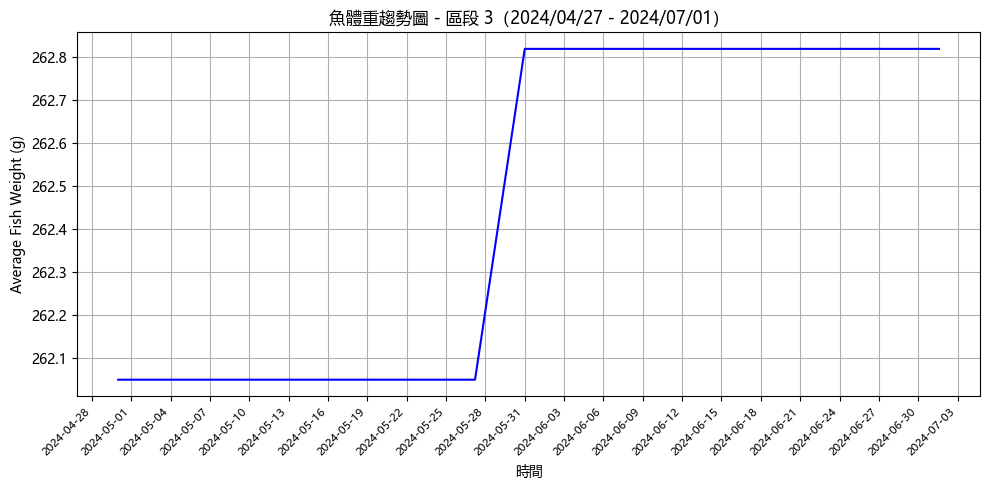

In [36]:
# Segment 3
plt.figure(figsize=(10, 5))
plt.plot(df_seg3.index, df_seg3['Average Fish Weight (g)'], color='blue')

# 顯示所有日期：每天顯示標籤
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))  # 每一天一格
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # 日期格式

plt.xticks(rotation=45, ha='right', fontsize=8)  # 旋轉日期以防重疊
plt.title("魚體重趨勢圖 - 區段 3（2024/04/27 - 2024/07/01）")
plt.xlabel("時間")
plt.ylabel("Average Fish Weight (g)")
plt.grid(True)
plt.tight_layout()
plt.show()

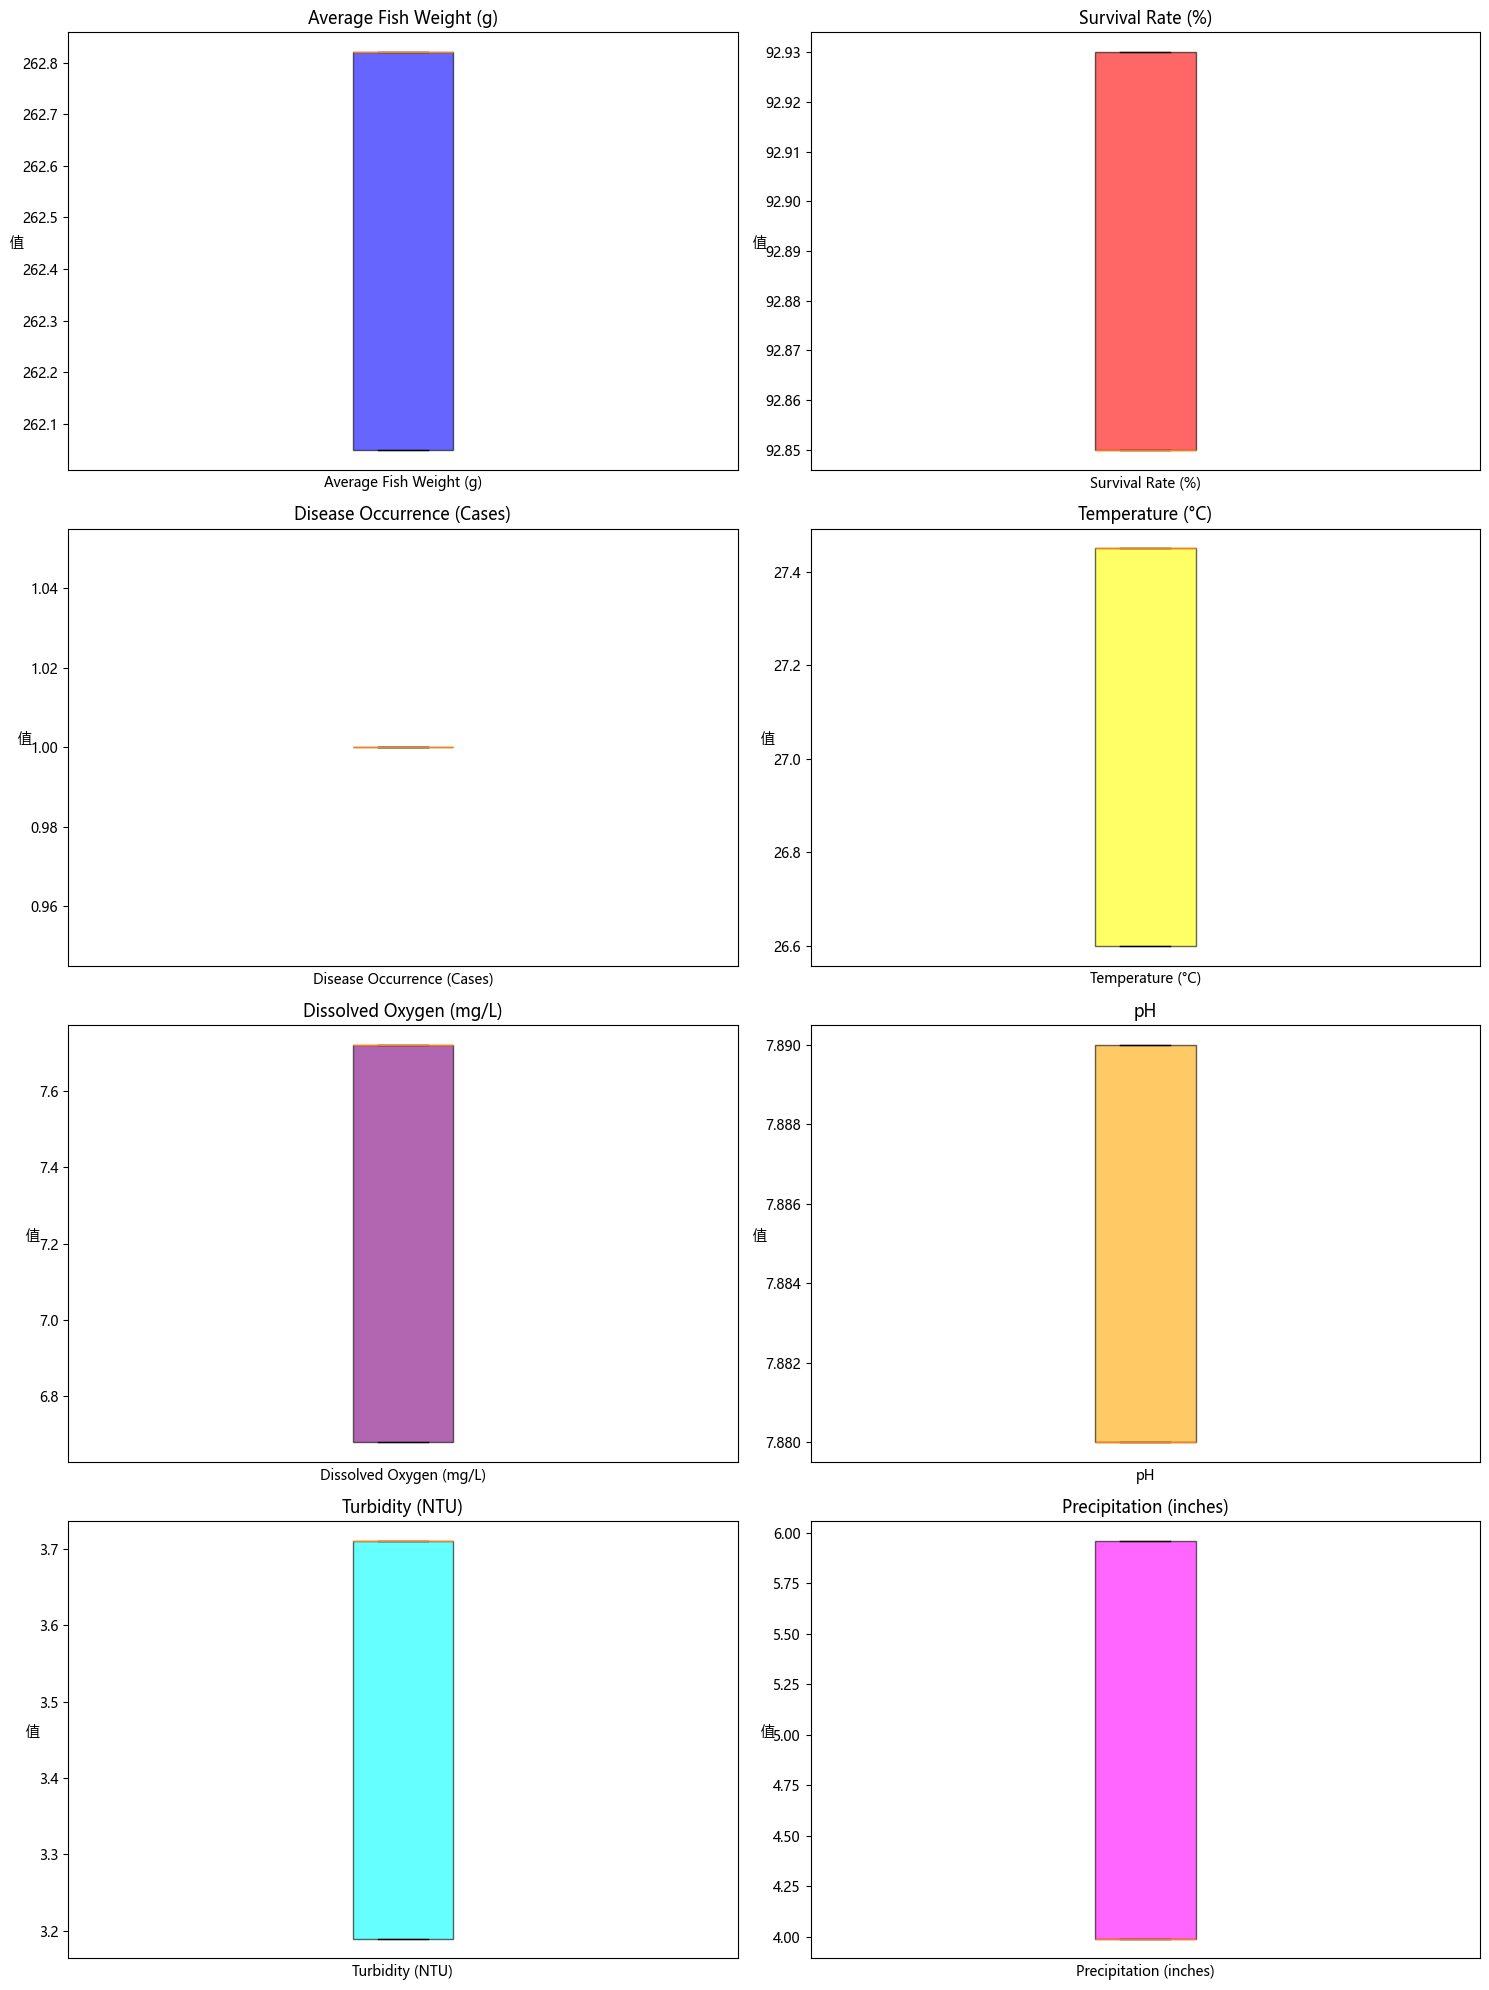

In [37]:
visualize_outliers(df_seg3)

In [38]:
df_seg3.to_csv('IoT Monitoring Dataset of Water Quality and Tilapia_Segment03.csv')

<h3> Normalize (min-max-scaler) </h3>
<ol> Note:為什麼使用min-max-scaler
    <li> 保留數據分佈的形狀。 </li>
    <li> 模型是LSTM，使用MinMaxScaler，將數據縮放到[0, 1] 範圍內，助於加快模型收斂速度。 </li>
    <li> Average Fish Weight (g) 資料屬於 有限範圍（262g ~ 286g）→ 適合壓縮到 [0, 1]。 </li>
    <li> 資料有階段性的跳躍區段，不適合 StandardScaler。 </li>
</ol>

In [39]:
normalizer = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。
df[df.columns.tolist()] = normalizer.fit_transform(df[df.columns.tolist()]) # 第一步：正規化數據
df

,Survival Rate (%),Disease Occurrence (Cases),Temperature (°C),Dissolved Oxygen (mg/L),pH,Turbidity (NTU),Precipitation (inches),Average Fish Weight (g)
Datetime,,,,,,,,
2024-01-01 00:00:00,0.701449,1.0,0.524324,0.000000,1.00000,0.428571,0.053819,0.563190
2024-01-01 01:00:00,0.701449,1.0,0.524324,0.000000,1.00000,0.428571,0.053819,0.563190
2024-01-01 02:00:00,0.701449,1.0,0.524324,0.000000,1.00000,0.428571,0.053819,0.563190
2024-01-01 03:00:00,0.701449,1.0,0.524324,0.000000,1.00000,0.428571,0.053819,0.563190
2024-01-01 04:00:00,0.701449,1.0,0.524324,0.000000,1.00000,0.428571,0.053819,0.563190
...,...,...,...,...,...,...,...,...
2024-07-01 10:00:00,0.000000,0.0,0.513514,0.890323,0.84375,0.773109,0.657986,0.031493
2024-07-01 11:00:00,0.000000,0.0,0.513514,0.890323,0.84375,0.773109,0.657986,0.031493
2024-07-01 12:00:00,0.000000,0.0,0.513514,0.890323,0.84375,0.773109,0.657986,0.031493


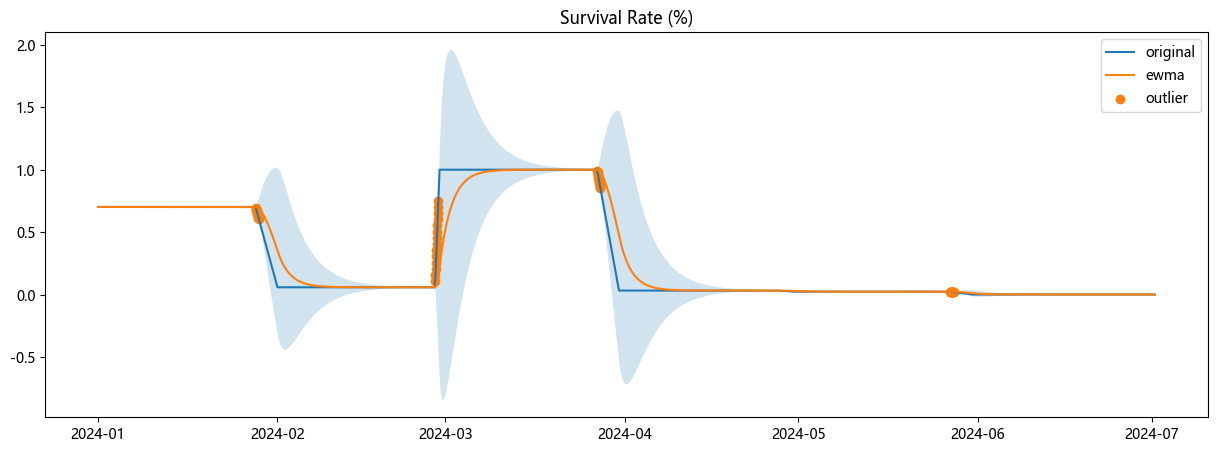

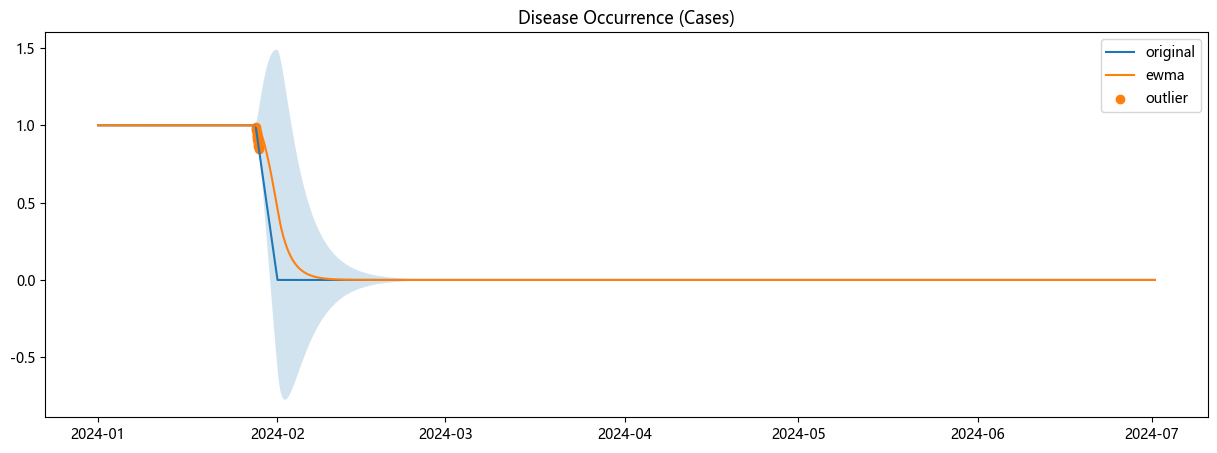

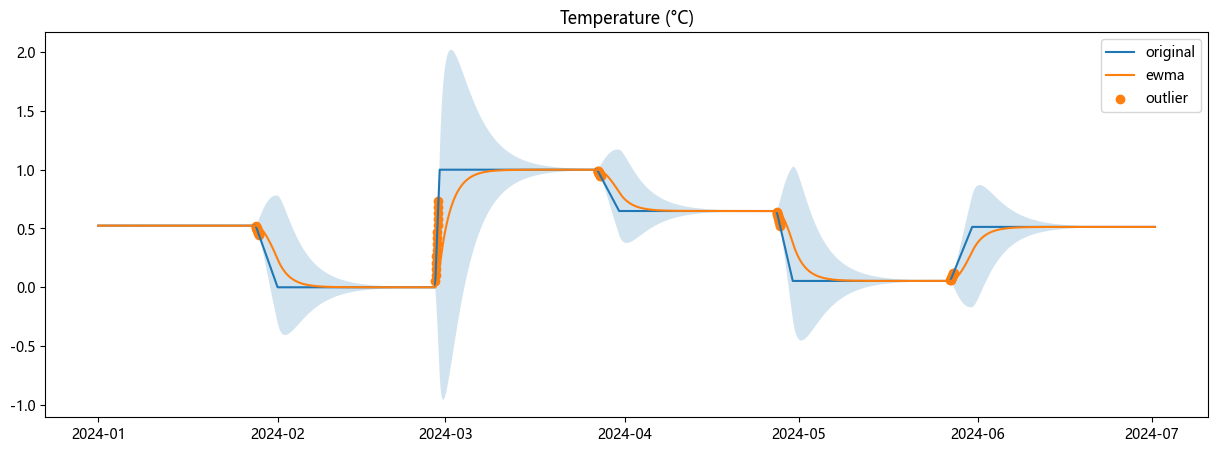

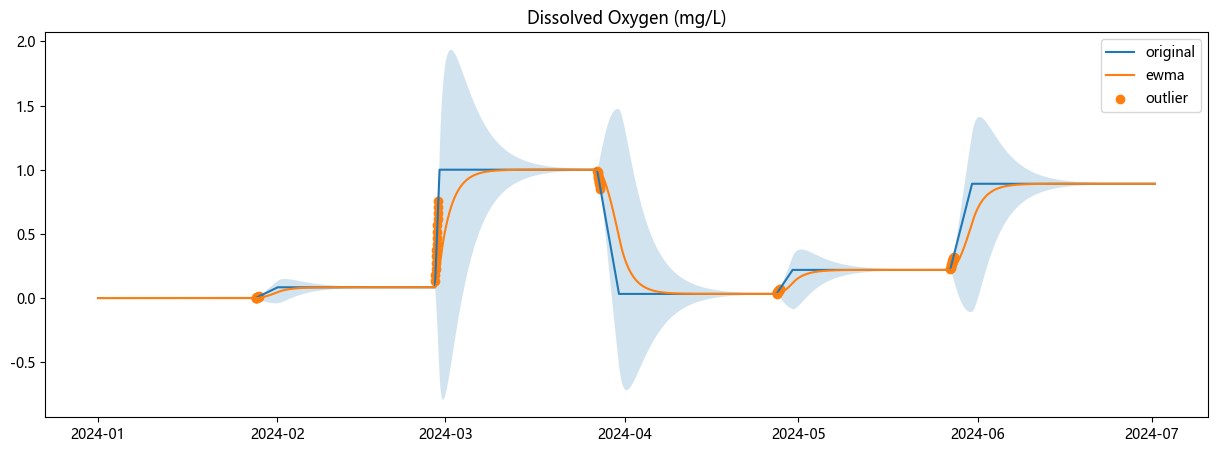

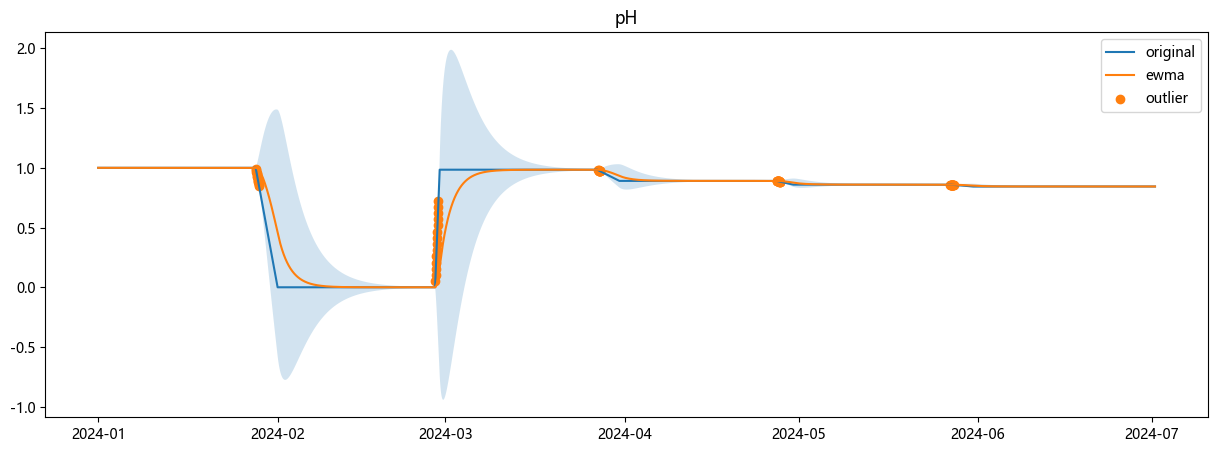

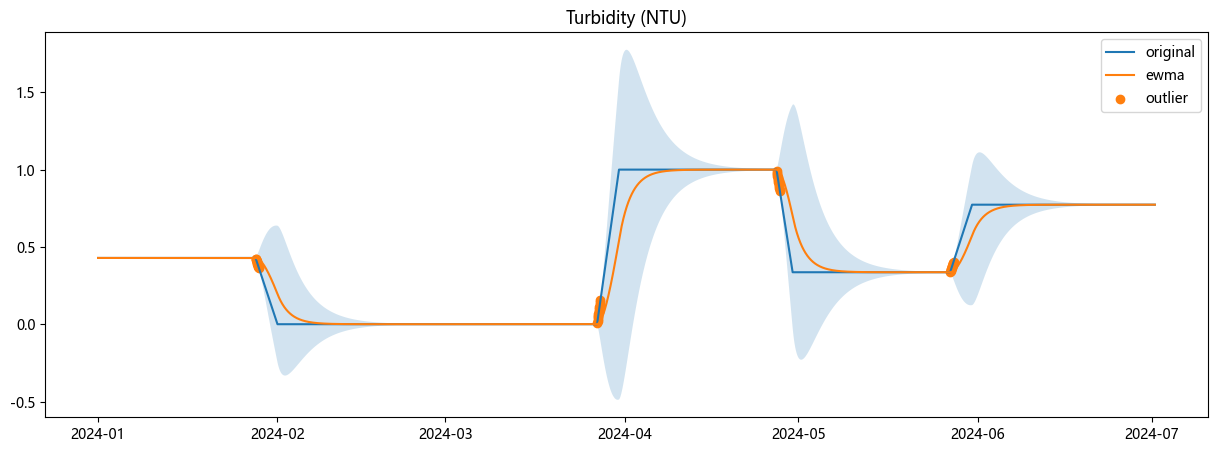

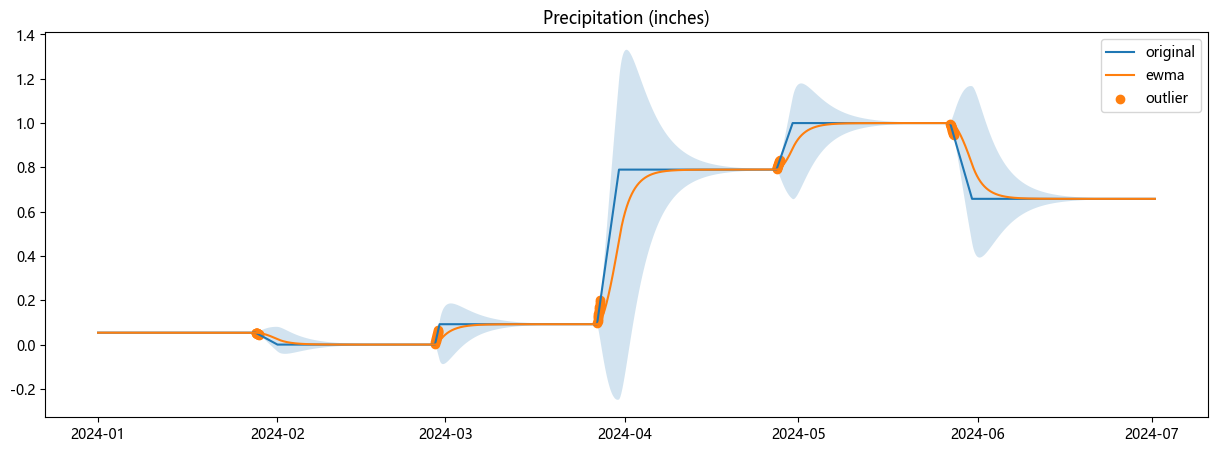

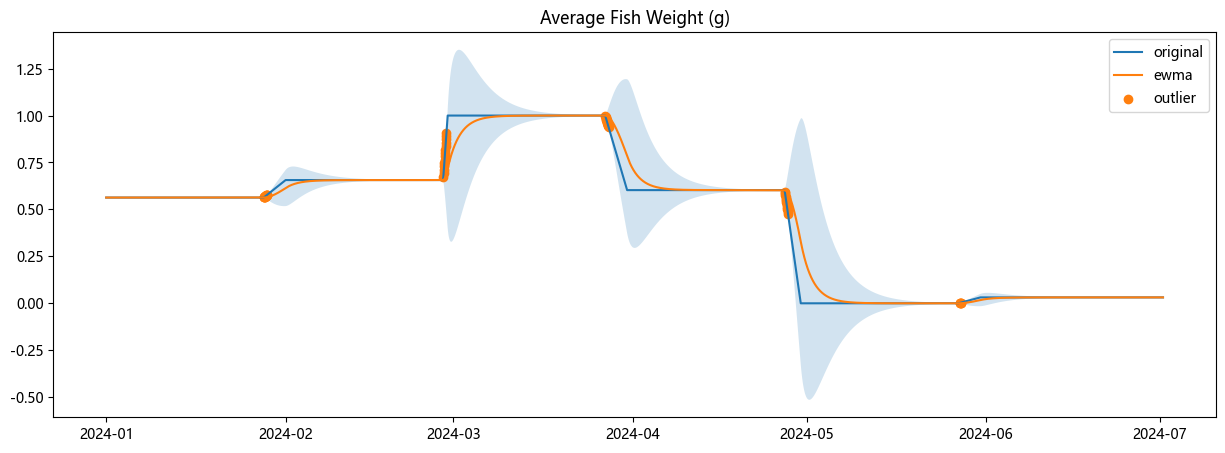

In [40]:
# save feature plot 
for n_column in df.columns:
    plot_outlier(df[n_column], n_column)

<p> Reference: Aquaponics Dataset Forecasting: Model Comparison </p>
https://www.kaggle.com/code/hocheping/aquaponics-dataset-forecasting-model-comparison/edit

<p> Reference:Aquaponics-Fish-Pond-Datasets-Forecasting-Model</p>
https://www.kaggle.com/code/hocheping/aquaponics-fish-pond-datasets-forecasting-model/edit

<h3> 證明為什麼 Average Fish Weight (g) 適合作為預測目標 </h3>

<p> Find correlations between attributes </p>

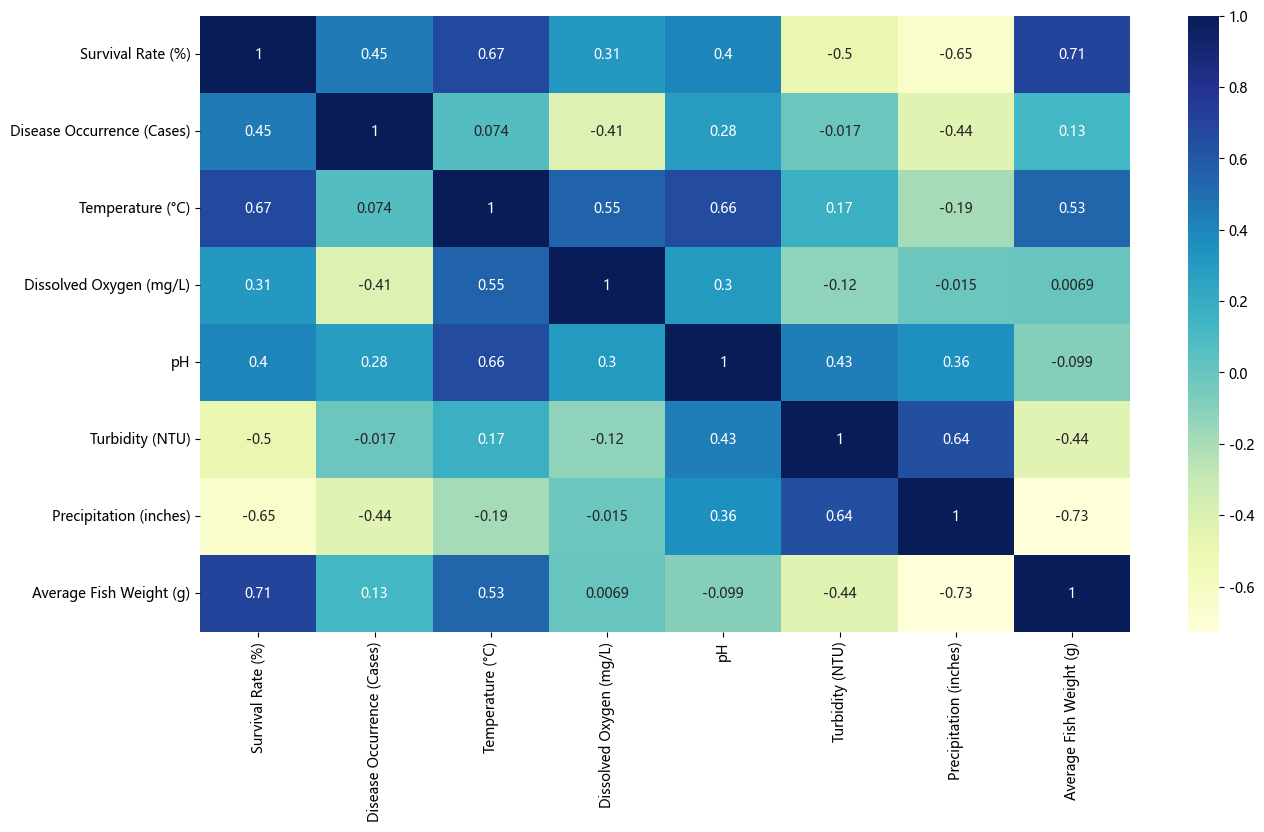

In [41]:
# using pearson's correlation to find the correlation between all the features
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(), cmap='YlGnBu', annot=True) # df.corr()
plt.show()

In [42]:
df.corr()['Average Fish Weight (g)']

Survival Rate (%)             0.706114
Disease Occurrence (Cases)    0.126096
Temperature (°C)              0.534666
Dissolved Oxygen (mg/L)       0.006857
pH                           -0.099416
Turbidity (NTU)              -0.442857
Precipitation (inches)       -0.726900
Average Fish Weight (g)       1.000000
Name: Average Fish Weight (g), dtype: float64

<ol>
    <li> R² 分數（決定係數，Coefficient of Determination）是一個評估回歸模型性能的指標，用於衡量模型對於數據變異的解釋能力。 </li>
    <li> R²=1：模型完美解釋數據。 </li>
    <li> R²=0：模型與目標值沒有關係。 </li>
    <li> R²<0：模型比隨機猜測更糟糕。 </li>
</ol>

In [43]:
def solve(X,y):

    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=1)

    # ------------------- Linear Regression -------------------
    # using linear regression (使用 普通線性回歸 方法對訓練數據進行建模。)
    # 找到一條直線，使得該直線可以最好地解釋特徵與目標值之間的線性關係。
    model = LinearRegression()
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print("R2_score of Linear Regression:",r2_score(y_test,y_pred))

    # ------------------- Lasso Regression --------------------
    # using Lasso regression (L1 正則化項)
    # Lasso 回歸會對不重要的特徵執行特徵選擇（即將某些權重變為 0），以減少過擬合。
    # 自動選擇重要特徵，並且能有效處理高維數據，提升模型的可解釋性。
    model = Lasso(alpha=0.001)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print("R2_score of Lasso Regression:",r2_score(y_test,y_pred))
    # print("Lasso Coefficients:", model.coef_)

    # ------------------- Ridge Regression ---------------------
    # using Ridge regression ( L2 正則化項)
    # Ridge 回歸會對所有權重施加懲罰，但不會將它們變為 0，適合處理多重共線性問題。
    model = Ridge(alpha=0.001)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print("R2_score of Ridge Regression:",r2_score(y_test,y_pred))

In [44]:
# df_seg1
X = df_seg1.drop(columns=['Average Fish Weight (g)']) # 所有欄位，除了 y
y = df_seg1['Average Fish Weight (g)'] # 預測目標
solve(X,y)

R2_score of Linear Regression: 1.0
R2_score of Lasso Regression: 0.9999993205506018
R2_score of Ridge Regression: 0.99999999999976


In [45]:
# df_seg2
X = df_seg2.drop(columns=['Average Fish Weight (g)']) # 所有欄位，除了 y
y = df_seg2['Average Fish Weight (g)'] # 預測目標
solve(X,y)

R2_score of Linear Regression: 1.0
R2_score of Lasso Regression: 0.9999952856749609
R2_score of Ridge Regression: 0.9999999999433754


C:\Users\HoChePing\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.417e+00, tolerance: 3.362e+00
  model = cd_fast.enet_coordinate_descent(


In [46]:
# df_seg3
X = df_seg3.drop(columns=['Average Fish Weight (g)']) # 所有欄位，除了 y
y = df_seg3['Average Fish Weight (g)'] # 預測目標
solve(X,y)

R2_score of Linear Regression: 1.0
R2_score of Lasso Regression: 0.9999923313885144
R2_score of Ridge Regression: 0.9999999999996564


<p> Reference: How to approach a dataset (EDA)- Learn With Me 如何使用資料集 （EDA）  </p>
https://www.kaggle.com/code/prakharjadaun/how-to-approach-a-dataset-eda-learn-with-me

<h3> Feature Importance 特徵重要性 </h3>

In [47]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
# df
X = df.drop(columns=['Average Fish Weight (g)']) # 所有欄位，除了 y
y = df['Average Fish Weight (g)'] # 預測目標

<p> 使用樹模型（如 Random Forest） </p>

In [49]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

model = RandomForestRegressor()
model.fit(X, y)

importance = model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                      Feature  Importance
0           Survival Rate (%)    0.847479
3     Dissolved Oxygen (mg/L)    0.149605
5             Turbidity (NTU)    0.000933
4                          pH    0.000837
6      Precipitation (inches)    0.000637
1  Disease Occurrence (Cases)    0.000256
2            Temperature (°C)    0.000253


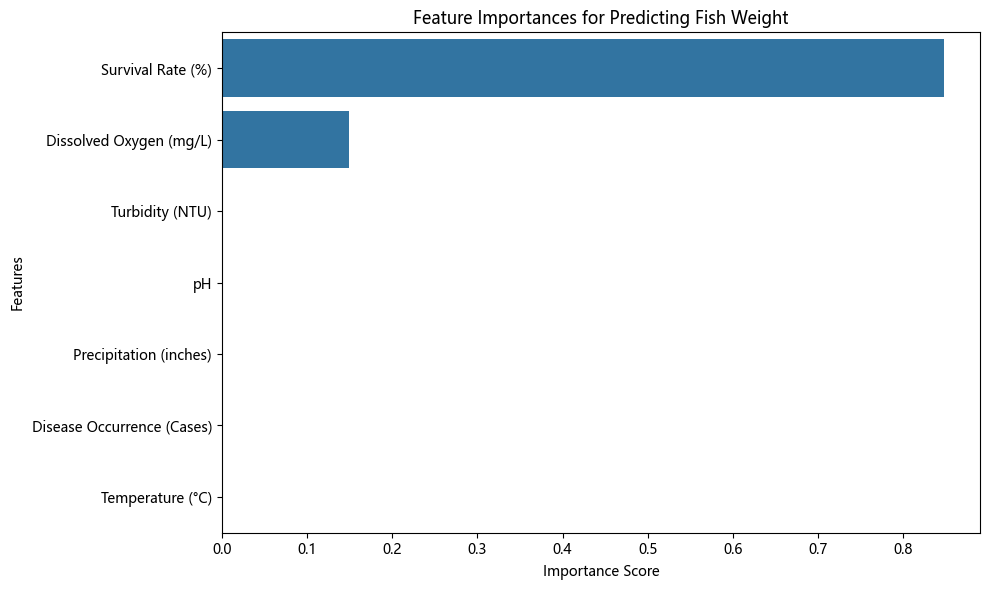

In [50]:
# 繪圖顯示特徵重要性
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances for Predicting Fish Weight')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1)

In [52]:
# 建立隨機森林模型
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [53]:
# 預測
y_pred = model.predict(X_test)

In [54]:
# 評估模型
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [55]:
# 特徵權重
feature_importances = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
feature_importances

Temperature (°C)              0.732180
Survival Rate (%)             0.461092
Turbidity (NTU)              -0.039656
pH                           -0.226375
Precipitation (inches)       -0.388644
Disease Occurrence (Cases)   -0.561236
Dissolved Oxygen (mg/L)      -0.616054
dtype: float64

In [56]:
# 顯示結果
print(f'Model Performance:\nMSE: {mse:.4f}\nR^2: {r2:.4f}')
print('\nTop Important Features:')
print(feature_importances)

Model Performance:
MSE: 0.0000
R^2: 1.0000

Top Important Features:
Temperature (°C)              0.732180
Survival Rate (%)             0.461092
Turbidity (NTU)              -0.039656
pH                           -0.226375
Precipitation (inches)       -0.388644
Disease Occurrence (Cases)   -0.561236
Dissolved Oxygen (mg/L)      -0.616054
dtype: float64


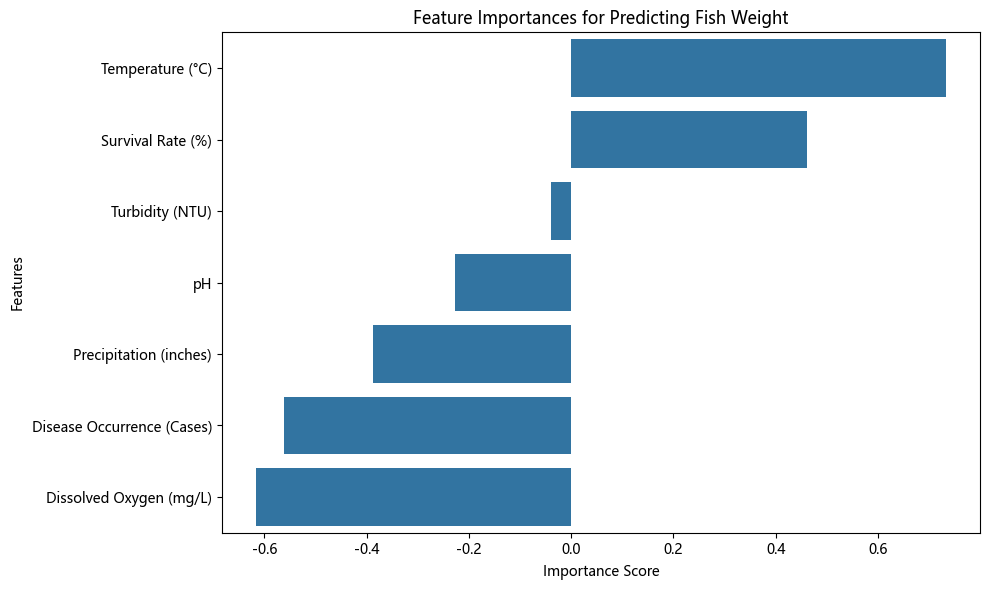

In [57]:
# 繪圖顯示特徵重要性
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances for Predicting Fish Weight')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

<h4> 用 Lasso Regression（看係數為 0 的欄位） </h4>

In [58]:
model = Lasso(alpha=1e-4)
model.fit(X, y)

coeff = pd.Series(model.coef_, index=X.columns)
print(coeff.sort_values(ascending=False))

Temperature (°C)              0.707222
Survival Rate (%)             0.512732
Turbidity (NTU)              -0.008185
pH                           -0.263615
Precipitation (inches)       -0.364286
Disease Occurrence (Cases)   -0.556395
Dissolved Oxygen (mg/L)      -0.604520
dtype: float64


C:\Users\HoChePing\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.259e-01, tolerance: 5.516e-02
  model = cd_fast.enet_coordinate_descent(


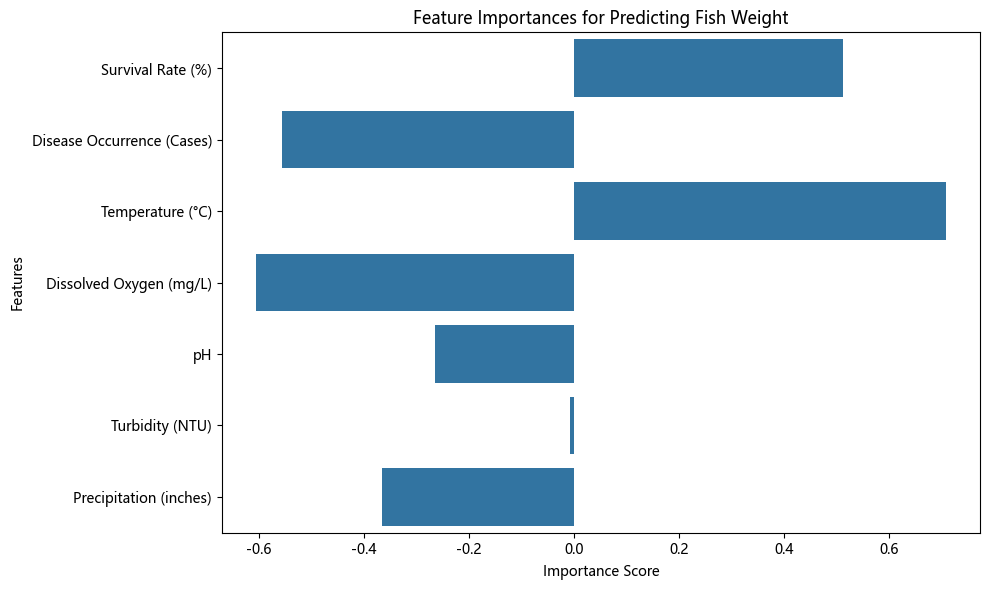

In [59]:
# 繪圖顯示特徵重要性
plt.figure(figsize=(10, 6))
sns.barplot(x=coeff, y=coeff.index)
plt.title('Feature Importances for Predicting Fish Weight')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()